# Reporte de ejemplos — Simulación de variables aleatorias

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---


<a id="introduccion"></a>
## 1. Introducción

Este cuaderno resuelve los seis ejercicios del archivo `10_Ejercicios_Simulacion.pdf`, dedicado a la **simulación de variables aleatorias**. El contenido combina dos técnicas que se complementan:

- **Simulación por transformación inversa.** A partir de una variable $U \sim \mathrm{Unif}(0,1)$ se aplica la función inversa de la distribución $F^{-1}$ para generar cualquier variable aleatoria continua. Los ejercicios 6.3 a 6.6 piden construir explícitamente la inversa de la distribución para la exponencial, la uniforme, la triangular y la de Weibull.
- **Pruebas no paramétricas sobre la muestra dada.** Los ejercicios 6.1 y 6.2 usan los mismos 30 números en $[0,1]$ para verificar, sin suponer una forma paramétrica, que la muestra es aleatoria y que sigue una $\mathrm{Unif}(0,1)$.

La estructura del cuaderno es la siguiente:

- **Ejercicio 6.1 (prueba de independencia).** Se aplica la prueba de rachas (Wald–Wolfowitz) con umbral en la media y en la mediana, se contrasta con la aproximación normal y con la distribución exacta de rachas, y se añade el contraste de Kendall sobre pares discordantes.
- **Ejercicio 6.2 (bondad de ajuste).** Se aplica la prueba de Kolmogorov–Smirnov de una muestra contra $\mathrm{Unif}(0,1)$, se muestran $D^+$ y $D^-$, y se confirma con chi-cuadrado y con un gráfico Q–Q.
- **Ejercicios 6.3 a 6.6 (simulación).** En cada caso se deriva la inversa de $F$ con `sympy`, se simula la muestra, y se valida comparando densidad, función de distribución, momentos y un Q–Q contra la distribución teórica.
- **Comparación conjunta.** Se muestra que las cuatro simulaciones comparten la misma estadística $D$ de Kolmogorov–Smirnov, consecuencia de que todas son transformadas monótonas de la misma variable $U$.

**Semilla.** Todas las simulaciones usan `numpy.random.default_rng(20260929)`, de modo que los resultados son reproducibles exactamente. Además, las cuatro simulaciones consumen **la misma realization de $U$**: es una decisión deliberada que hace visible la idea de que la simulación por inversión solo cambia la transformación, no la fuente de azar.


<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Marco conceptual](#marco)
- [5. Ejercicio 6.1 — Prueba de independencia (prueba de rachas)](#ej61)
- [6. Ejercicio 6.2 — Prueba de bondad de ajuste (Kolmogorov–Smirnov)](#ej62)
- [7. Ejercicio 6.3 — Simulación exponencial por inversión](#ej63)
- [8. Ejercicio 6.4 — Simulación uniforme por inversión](#ej64)
- [9. Ejercicio 6.5 — Simulación triangular por inversión](#ej65)
- [10. Ejercicio 6.6 — Simulación Weibull por inversión](#ej66)
- [11. Comparación conjunta de las cuatro simulaciones](#comparacion)
- [12. Resumen comparativo](#resumen)
- [13. Conclusiones](#conclusiones)


<a id="setup"></a>
## 3. Configuración inicial


In [1]:
import itertools
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sympy as sp
from scipy import stats as st

sp.init_printing(use_latex="mathjax")

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"   # estadistico observado / decision
COLOR_CRITICAL = "#e34948"    # region de rechazo
COLOR_NULO = "#52514e"        # valor esperado bajo H0
COLOR_UNIF = PALETTE_CATEGORICAL[0]
COLOR_EXP = PALETTE_CATEGORICAL[1]
COLOR_TRI = PALETTE_CATEGORICAL[2]
COLOR_WEI = PALETTE_CATEGORICAL[3]

SEED = 20260929
N_SIM = 20_000
ALPHA = 0.05

print("Entorno listo.")
print(f"  Python {__import__('sys').version.split()[0]}")
print(f"  numpy {np.__version__} | scipy {st.__name__ and __import__('scipy').__version__}")
print(f"  semilla={SEED}  n_sim={N_SIM}  alpha={ALPHA}")

Entorno listo.
  Python 3.12.14
  numpy 2.5.3 | scipy 1.18.1
  semilla=20260929  n_sim=20000  alpha=0.05


In [2]:
# Muestra de los ejercicios 6.1 y 6.2 (30 valores en [0, 1])
datos = np.array([
    0.37294820, 0.16027056, 0.05449612, 0.83599578, 0.15381606,
    0.37944775, 0.93973558, 0.92010324, 0.06905788, 0.48806466,
    0.34190794, 0.70548178, 0.41387924, 0.98497968, 0.34043183,
    0.41924317, 0.69263500, 0.94783417, 0.51454376, 0.03760117,
    0.19221610, 0.38556106, 0.49306548, 0.23262602, 0.77631701,
    0.40966361, 0.44812154, 0.11920097, 0.70576410, 0.05322840,
])

n = datos.size
print(f"n = {n} valores")
print(f"minimo   = {datos.min():.8f}")
print(f"maximo   = {datos.max():.8f}")
print(f"media    = {datos.mean():.8f}")
print(f"mediana  = {np.median(datos):.8f}")
print(f"varianza = {datos.var(ddof=1):.8f}   (s = {datos.std(ddof=1):.8f})")
print()
print("orden original (para las pruebas que dependen del orden):")
print(" ".join(f"{v:.4f}" for v in datos))
print()
print("esta ordenado de forma creciente?", bool(np.all(np.diff(datos) > 0)))

n = 30 valores
minimo   = 0.03760117
maximo   = 0.98497968
media    = 0.45294126
mediana  = 0.41177142
varianza = 0.08667592   (s = 0.29440774)

orden original (para las pruebas que dependen del orden):
0.3729 0.1603 0.0545 0.8360 0.1538 0.3794 0.9397 0.9201 0.0691 0.4881 0.3419 0.7055 0.4139 0.9850 0.3404 0.4192 0.6926 0.9478 0.5145 0.0376 0.1922 0.3856 0.4931 0.2326 0.7763 0.4097 0.4481 0.1192 0.7058 0.0532

esta ordenado de forma creciente? False


<a id="marco"></a>
## 4. Marco conceptual

### 4.1 Método de transformación inversa

Sea $U \sim \mathrm{Unif}(0,1)$ y sea $F$ la función de distribución acumulada (CDF) de una
variable aleatoria continua $X$, acotada e estrictamente creciente en su soporte. La
**transformación inversa** define

$$
X = F^{-1}(U) = \inf\{x : F(x) \geq u\}, \qquad u = U.
$$

**Demostración.** Para cualquier $x$ en el soporte,

$$
P\big(X \leq x\big) = P\big(F^{-1}(U) \leq x\big)
= P\big(U \leq F(x)\big) = F(x),
$$

pues $F$ es continua y estrictamente creciente, de modo que $\{F^{-1}(u) \leq x\} = \{u \leq F(x)\}$.
Como $U$ es uniforme, $P(U \leq F(x)) = F(x)$, que es precisamente la CDF de $X$. $\blacksquare$

**Verificación de la CDF con `sympy`.** Si la inversa es correcta, al sustituir $x = F^{-1}(u)$
en la expresión de la CDF debe obtenerse exactamente $u$:

$$
F\big(F^{-1}(u)\big) = u \qquad \forall\, u \in (0,1).
$$

Esa identidad es la que se comprueba numéricamente en cada ejercicio.

**Algoritmo en tres pasos.**

1. Generar $u_1, \dots, u_n$ con `rng.random(n)`, es decir $U_i \sim \mathrm{Unif}(0,1)$ i.i.d.
2. Calcular $x_i = F^{-1}(u_i)$ con la fórmula cerrada.
3. Devolver $\hat{x} = (x_1, \dots, x_n)$, que es una muestra aleatoria simple de la distribución de $X$.

**Supuesto clave:** el vector $\hat{x}$ es una muestra **i.i.d.** de $X$, porque las $u_i$ son
i.i.d. y la transformación $F^{-1}$ es determinista. El único paso que introduce aleatoriedad
es la generación de los $u_i$.

### 4.2 Prueba de rachas (independencia)

La **racha** es una cadena maximal de valores consecutivos del mismo tipo. Se elige un umbral
$c$ y se etiqueta cada observación como *arriba* ($x_i > c$) o *abajo* ($x_i \leq c$). El número
de rachas $R$ es el número de cambios de etiqueta más uno:

$$
R = 1 + \sum_{i=2}^{n} \mathbf{1}\big(x_i > c\;\neq\; x_{i-1} > c\big).
$$

Bajo $H_0$ (**las observaciones son aleatorias e independientes**), la etiqueta es un
proceso de Bernoulli y $R$ sigue una distribución conocida con

$$
E[R] = \frac{2 n_1 n_2}{n} + 1,
\qquad
\mathrm{Var}(R) = \frac{2 n_1 n_2\,(2 n_1 n_2 - n)}{n^2 (n - 1)},
$$

donde $n_1$ y $n_2$ son los conteos arriba y abajo. Para $n \geq 20$ se usa la aproximación
normal $Z = (R - E[R])/\mathrm{sd}(R)$, y para muestras pequeñas la distribución exacta se
obtiene enumerando las $\binom{n}{n_1}$ repartos posibles.

- **$H_0$:** la secuencia es aleatoria (independencia).
- **$H_1$:** la secuencia no es aleatoria (hay tendencia o agrupamiento).
- **Región de rechazo:** $R \leq \mu_R - z_{\alpha/2}\,\mathrm{sd}(R)$ o $R \geq \mu_R + z_{\alpha/2}\,\mathrm{sd}(R)$.

Un valor de $R$ **cercano** a $\mu_R$ indica alternancia (comportamiento aleatorio); un valor
**muy alto** indica **mucha** alternancia (agrupamiento en bloques) y uno **muy bajo** indica
agrupamiento en dos bloques.

### 4.3 Prueba de Kolmogorov–Smirnov de una muestra

Compara la función de distribución empírica

$$
F_n(x) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}(x_{(i)} \leq x)
$$

con la CDF teórica $F_0$. El estadístico es la mayor discrepancia vertical:

$$
D = \sup_x \big| F_n(x) - F_0(x) \big|
= \max\Big( D^+,\; D^- \Big),
$$

con

$$
D^+ = \max_i \Big( \tfrac{i}{n} - F_0(x_{(i)}) \Big),
\qquad
D^- = \max_i \Big( F_0(x_{(i)}) - \tfrac{i-1}{n} \Big).
$$

Bajo $H_0$ la ley de $D$ no depende de $F_0$ (propiedad de Kolmogorov), y para $n$ moderado se
usa $\sqrt{n}\,D \overset{d}{\to} K$ con $K$ la distribución de Kolmogorov. Para el caso
particular $F_0 = \mathrm{Unif}(0,1)$ se cumple exactamente

$$
F_0(x) = x,
$$

de modo que $D^+ = \max_i \frac{i}{n} - x_{(i)}$ y $D^- = \max_i x_{(i)} - \frac{i-1}{n}$: las
fórmulas se simplifican sin necesidad de estimar ningún parámetro.


In [3]:
def distribucion_exacta_rachas(n1, n2):
    # Devuelve {R: P(R)} exacta bajo independencia, por programacion dinamica.
    # Una secuencia binaria queda determinada por como se reparten n1 unos y n2 ceros
    # en rachas; se cuentan las secuencias con exactamente R rachas.
    estados = {(0, 0, None, 0): 1}
    for _ in range(n1 + n2):
        siguientes = {}
        for (a, b, ultimo, r), cuenta in estados.items():
            if a < n1:
                clave = (a + 1, b, 1, r + (ultimo != 1))
                siguientes[clave] = siguientes.get(clave, 0) + cuenta
            if b < n2:
                clave = (a, b + 1, 0, r + (ultimo != 0))
                siguientes[clave] = siguientes.get(clave, 0) + cuenta
        estados = siguientes

    conteo_rachas = {}
    for (_, _, _, r), cuenta in estados.items():
        conteo_rachas[r] = conteo_rachas.get(r, 0) + cuenta

    total = math.comb(n1 + n2, n1)
    return {r: c / total for r, c in sorted(conteo_rachas.items())}, total


def prueba_rachas(x, c, alpha=0.05, nombre="umbral"):
    # Prueba de rachas de Wald-Wolfowitz para el vector x con umbral c.
    arriba = (x > c).astype(int)
    rachas = 1 + int(np.sum(arriba[1:] != arriba[:-1]))
    n1 = int(arriba.sum())
    n2 = x.size - n1

    media = 2 * n1 * n2 / x.size + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - x.size)) / (x.size ** 2 * (x.size - 1))
    sd = math.sqrt(var)

    z = (rachas - media) / sd
    z_cc = (rachas - media - math.copysign(0.5, rachas - media)) / sd
    p_normal = 2 * (1 - st.norm.cdf(abs(z)))
    p_normal_cc = 2 * (1 - st.norm.cdf(abs(z_cc)))

    exacta, _ = distribucion_exacta_rachas(n1, n2)
    p_exacta = sum(pr for r, pr in exacta.items() if abs(r - media) >= abs(rachas - media))

    zc = st.norm.ppf(1 - alpha / 2)
    return {
        "nombre": nombre, "umbral": c, "n1": n1, "n2": n2, "rachas": rachas,
        "media": media, "sd": sd, "z": z, "z_cc": z_cc,
        "p_normal": p_normal, "p_normal_cc": p_normal_cc, "p_exacta": p_exacta,
        "rechazo_bajo": math.floor(media - zc * sd),
        "rechazo_alto": math.ceil(media + zc * sd),
        "distribucion": exacta,
    }


def decision(p_valor, alpha, h0_desc, h1_desc,Conclusion=True):
    if p_valor <= alpha:
        texto = f"Se rechaza H0 (valor-p = {p_valor:.6f} <= alpha = {alpha})"
    else:
        texto = f"No se rechaza H0 (valor-p = {p_valor:.6f} > alpha = {alpha})"
    if Conclusion:
        print(f"  H0       : {h0_desc}")
        print(f"  H1       : {h1_desc}")
        print(f"  alpha    : {alpha}")
        print(f"  valor-p  : {p_valor:.6f}")
        print(f"  Decision : {'Rechazar H0' if p_valor <= alpha else 'No rechazar H0'}")
    return texto


print("Utilidades cargadas.")
prueba = prueba_rachas(np.array([1, 1, 0, 1, 0, 0, 1, 1, 1, 0]), 0.5, nombre="prueba")
print("Comprobacion rapida con 10 valores, umbral 0.5:")
print(f"  n1={prueba['n1']} n2={prueba['n2']} R={prueba['rachas']} "
      f"E[R]={prueba['media']:.2f} p_exacta={prueba['p_exacta']:.6f}")
print(f"  La suma de la distribucion exacta es {sum(prueba['distribucion'].values()):.12f}")

Utilidades cargadas.
Comprobacion rapida con 10 valores, umbral 0.5:
  n1=6 n2=4 R=6 E[R]=5.80 p_exacta=1.000000
  La suma de la distribucion exacta es 1.000000000000


<a id="ej61"></a>
## 5. Ejercicio 6.1 — Prueba de independencia de la muestra

**Enunciado.** Verificar que la siguiente muestra es aleatoria con un nivel de significación de
0.05:

$$
(0.3729482,\ 0.16027056,\ 0.05449612,\ \dots,\ 0.0532284).
$$

**Planteamiento.** La pregunta es si los 30 valores, **en el orden en que se dieron**, se
comportan como el resultado de un experimento aleatorio. Este es exactamente el supuesto de
**independencia** que sostiene a toda la inferencia estadística posterior, así que conviene
comprobarlo antes de usar la muestra.

- **$H_0$:** la secuencia es aleatoria; las observaciones son independientes.
- **$H_1$:** la secuencia no es aleatoria; hay tendencia o agrupamiento.
- **Nivel de significación:** $\alpha = 0.05$.

El estadístico adecuado es el **número de rachas** $R$. La clave de lectura es:

| Comportamiento | Número de rachas | Interpretación |
|----------------|------------------|----------------|
| Muy pocas rachas | $R \ll E[R]$ | Los valores se agrupan en dos o tres bloques: hay **tendencia** (creciente o decreciente). |
| Rachas aleatorias | $R \approx E[R]$ | Las etiquetas se alternan como esperaría el azar. |
| Muchas rachas | $R \gg E[R]$ | Máxima alternancia, también compatible con el azar. |

Como el umbral $c$ no viene dado, la práctica habitual es usar la **media** de la muestra o su
**mediana**. Se reportan ambas porque la elección del umbral no debe cambiar la conclusión; si
cambia, la evidencia es frágil.


In [4]:
# Umbrales candidatos: media y mediana de la muestra
umbral_media = datos.mean()
umbral_mediana = float(np.median(datos))

r_media = prueba_rachas(datos, umbral_media, ALPHA, nombre="media")
r_mediana = prueba_rachas(datos, umbral_mediana, ALPHA, nombre="mediana")

for r in (r_media, r_mediana):
    print(f"=== Umbral en la {r['nombre']}  (c = {r['umbral']:.8f}) ===")
    print(f"  n1 (arriba)   = {r['n1']}")
    print(f"  n2 (abajo)    = {r['n2']}")
    print(f"  R observado   = {r['rachas']}")
    print(f"  E[R]          = {r['media']:.4f}")
    print(f"  sd(R)         = {r['sd']:.4f}")
    print(f"  z             = {r['z']:.6f}")
    print(f"  z (con cc)    = {r['z_cc']:.6f}")
    print(f"  valor-p normal            = {r['p_normal']:.6f}")
    print(f"  valor-p normal (con cc)   = {r['p_normal_cc']:.6f}")
    print(f"  valor-p exacto            = {r['p_exacta']:.6f}")
    print(f"  Region de rechazo         = R <= {r['rechazo_bajo']}  o  R >= {r['rechazo_alto']}")
    print()

=== Umbral en la media  (c = 0.45294126) ===
  n1 (arriba)   = 12
  n2 (abajo)    = 18
  R observado   = 19
  E[R]          = 15.4000
  sd(R)         = 2.5795
  z             = 1.395622
  z (con cc)    = 1.201786
  valor-p normal            = 0.162828
  valor-p normal (con cc)   = 0.229447
  valor-p exacto            = 0.180422
  Region de rechazo         = R <= 10  o  R >= 21

=== Umbral en la mediana  (c = 0.41177142) ===
  n1 (arriba)   = 15
  n2 (abajo)    = 15
  R observado   = 19
  E[R]          = 16.0000
  sd(R)         = 2.6910
  z             = 1.114835
  z (con cc)    = 0.929029
  valor-p normal            = 0.264921
  valor-p normal (con cc)   = 0.352874
  valor-p exacto            = 0.349819
  Region de rechazo         = R <= 10  o  R >= 22



In [5]:
# Secuencia binaria bajo el umbral en la media
secuencia = (datos > umbral_media).astype(int)
rachas_detalle = [(k, len(list(g))) for k, g in itertools.groupby(secuencia)]

print("Secuencia umbralada (1 = arriba de la media, 0 = abajo):")
print("  " + "".join(str(b) for b in secuencia))
print()
print("Rachas resultantes (valor, longitud):")
for i, (valor, largo) in enumerate(rachas_detalle, start=1):
    print(f"  racha {i:>2}: {'arriba' if valor else 'abajo ':<6} x {largo}")
print()
print(f"Número total de rachas = {len(rachas_detalle)}")

Secuencia umbralada (1 = arriba de la media, 0 = abajo):
  000100110101010011100010100010

Rachas resultantes (valor, longitud):
  racha  1: abajo  x 3
  racha  2: arriba x 1
  racha  3: abajo  x 2
  racha  4: arriba x 2
  racha  5: abajo  x 1
  racha  6: arriba x 1
  racha  7: abajo  x 1
  racha  8: arriba x 1
  racha  9: abajo  x 1
  racha 10: arriba x 1
  racha 11: abajo  x 2
  racha 12: arriba x 3
  racha 13: abajo  x 3
  racha 14: arriba x 1
  racha 15: abajo  x 1
  racha 16: arriba x 1
  racha 17: abajo  x 3
  racha 18: arriba x 1
  racha 19: abajo  x 1

Número total de rachas = 19


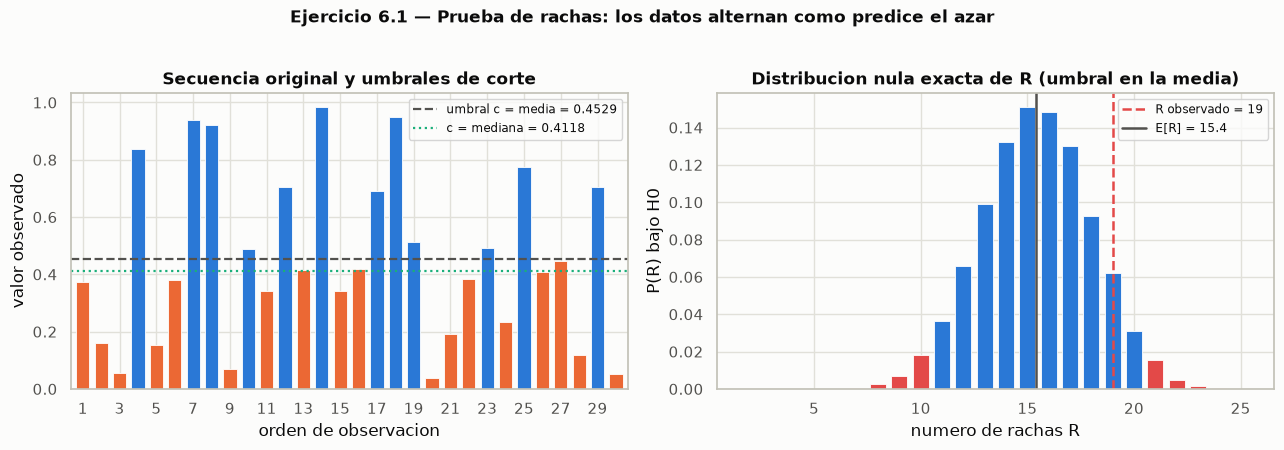

In [6]:
# Figura 6.1: secuencia umbralada y distribucion nula del numero de rachas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# Panel izquierdo: la secuencia y sus rachas
colores = [COLOR_UNIF if b else COLOR_EXP for b in secuencia]
ax1.bar(np.arange(1, n + 1), datos, color=colores, width=0.72,
        edgecolor="white", linewidth=0.6)
ax1.axhline(umbral_media, color=COLOR_NULO, linestyle="--", linewidth=1.6,
            label=f"umbral c = media = {umbral_media:.4f}")
ax1.axhline(umbral_mediana, color=PALETTE_CATEGORICAL[2], linestyle=":",
            linewidth=1.6, label=f"c = mediana = {umbral_mediana:.4f}")
ax1.set_xlabel("orden de observacion")
ax1.set_ylabel("valor observado")
ax1.set_title("Secuencia original y umbrales de corte", fontweight="bold")
ax1.set_xticks(np.arange(1, n + 1, 2))
ax1.legend(frameon=True, fontsize=8.5, loc="upper right")
ax1.margins(x=0.01)

# Panel derecho: distribucion nula de R con la region de rechazo
dist = r_media["distribucion"]
valores_r = np.array(sorted(dist))
probabilidades = np.array([dist[r] for r in valores_r])
colores_bar = [
    COLOR_CRITICAL if (r <= r_media["rechazo_bajo"] or r >= r_media["rechazo_alto"])
    else COLOR_UNIF
    for r in valores_r
]
ax2.bar(valores_r, probabilidades, color=colores_bar, width=0.75,
        edgecolor="white", linewidth=0.6)
ax2.axvline(r_media["rachas"], color=COLOR_HIGHLIGHT, linestyle="--",
            linewidth=1.8, label=f"R observado = {r_media['rachas']}")
ax2.axvline(r_media["media"], color=COLOR_NULO, linewidth=1.8,
            label=f"E[R] = {r_media['media']:.1f}")
ax2.set_xlabel("numero de rachas R")
ax2.set_ylabel("P(R) bajo H0")
ax2.set_title("Distribucion nula exacta de R (umbral en la media)", fontweight="bold")
ax2.legend(frameon=True, fontsize=8.5)
ax2.set_ylim(bottom=0)

fig.suptitle("Ejercicio 6.1 — Prueba de rachas: los datos alternan como predice el azar",
             fontsize=12.5, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [7]:
# Robustez: el resultado no debe depender del umbral elegido
print("Barrido de umbrales entre los cuantiles 20% y 90%")
print(f"{'cuantil':>9} {'c':>10} {'n1':>4} {'n2':>4} {'R':>4} {'E[R]':>8} {'z':>8} {'p exacto':>10} {'decision':>14}")
for q in np.arange(0.2, 0.95, 0.1):
    c = float(np.quantile(datos, q))
    r = prueba_rachas(datos, c, ALPHA, nombre=f"q{q:.1f}")
    veredicto = "rechazar" if r["p_exacta"] <= ALPHA else "no rechazar"
    print(f"{q:>9.1f} {c:>10.4f} {r['n1']:>4} {r['n2']:>4} {r['rachas']:>4} "
          f"{r['media']:>8.2f} {r['z']:>8.4f} {r['p_exacta']:>10.6f} {veredicto:>14}")
print()
print(" ningun umbral rechaza H0: la conclusion es robusta a la eleccion del corte.")

Barrido de umbrales entre los cuantiles 20% y 90%
  cuantil          c   n1   n2    R     E[R]        z   p exacto       decision
      0.2     0.1590   24    6   12    10.60   0.8297   0.552608    no rechazar
      0.3     0.3081   21    9   14    13.60   0.1782   1.000000    no rechazar
      0.4     0.3768   18   12   17    15.40   0.6203   0.568288    no rechazar
      0.5     0.4118   15   15   19    16.00   1.1148   0.349819    no rechazar
      0.6     0.4641   12   18   19    15.40   1.3956   0.180422    no rechazar
      0.7     0.5680    9   21   15    13.60   0.6236   0.666235    no rechazar
      0.8     0.7199    6   24   11    10.60   0.2371   1.000000    no rechazar
      0.9     0.9221    3   27    7     6.40   0.6629   0.839901    no rechazar

 ningun umbral rechaza H0: la conclusion es robusta a la eleccion del corte.


### 5.5 Contraste con el estadístico de Kendall

La prueba de rachas solo mira la etiqueta relativa al umbral. Un segundo contraste, que no
requiere elegir umbral, es el **tau de Kendall**, basado en los pares discordantes
(*discordant pairs*):

$$
\tau = 1 - \frac{4D}{n(n-1)},
$$

donde $D$ es el número de pares $(i, j)$ con $i < j$ y $x_i > x_j$. Si la secuencia fuera
aleatoria, aproximadamente la mitad de los pares serían discordantes y $\tau \approx 0$.


In [8]:
# Pares discordantes y tau de Kendall
pares_totales = n * (n - 1) / 2
discordantes = sum(1 for i, j in itertools.combinations(range(n), 2) if datos[i] > datos[j])
tau = 1 - 2 * discordantes / pares_totales

print(f"pares totales (i < j)      = {int(pares_totales)}")
print(f"pares discordantes        = {discordantes}")
print(f"pares concordantes        = {int(pares_totales - discordantes)}")
print(f"proporcion discordante    = {discordantes / pares_totales:.6f}  (0.5 si es aleatoria)")
print(f"tau de Kendall            = {tau:.6f}")
print()
# Series de Kendall sobre la misma muestra, como referencia
for tau_n in (1, 2, 3):
    valor, p_valor = st.kendalltau(np.arange(n), datos, method="asymptotic") if tau_n == 1 else (None, None)
    if valor is not None:
        print(f"tau de Kendall de la serie (orden vs valor) = {valor:.6f}, valor-p = {p_valor:.6f}")
        break
print()
print("Una tau practicamente nula confirma que el valor no guarda relacion con su posicion.")

pares totales (i < j)      = 435
pares discordantes        = 218
pares concordantes        = 217
proporcion discordante    = 0.501149  (0.5 si es aleatoria)
tau de Kendall            = -0.002299

tau de Kendall de la serie (orden vs valor) = -0.002299, valor-p = 0.985766

Una tau practicamente nula confirma que el valor no guarda relacion con su posicion.


<a id="ej62"></a>
## 6. Ejercicio 6.2 — Prueba de bondad de ajuste

**Enunciado.** Validar que la misma muestra se distribuye como una $\mathrm{Unif}(0,1)$ con un
nivel de significación de 0.05. La decisión se expresa en una de estas dos proposiciones:

- Los datos **se distribuyen** como una $\mathrm{Unif}(0,1)$.
- Los datos **no se distribuyen** como una $\mathrm{Unif}(0,1)$.

- **$H_0$:** la muestra proviene de una $\mathrm{Unif}(0,1)$.
- **$H_1$:** la muestra no proviene de una $\mathrm{Unif}(0,1)$.
- **Nivel de significación:** $\alpha = 0.05$.

Como $F_0(x) = x$ en $[0,1]$, la prueba se simplifica: no hay parámetros que estimar y el
estadístico $D$ se calcula directamente sobre los datos.

Es importante recordar el alcance lógico de la conclusión. **No rechazar $H_0$ no demuestra que
la muestra sea uniforme**: solo indica que los datos no contienen evidencia suficiente en contra.
Una muestra de 30 puntos de cualquier distribución se parece a una $\mathrm{Unif}(0,1)$ con
mucha frecuencia, de modo que la potencia de esta prueba es baja para desviaciones pequeñas.


In [9]:
# Calculo manual de D+ y D- para F0(x) = x
ordenados = np.sort(datos)
i = np.arange(1, n + 1)

D_mas = i / n - ordenados          # exceso de la ECDF sobre la teorica
D_menos = ordenados - (i - 1) / n  # exceso de la teorica sobre la ECDF

indice_Dp = int(np.argmax(D_mas))
indice_Dm = int(np.argmax(D_menos))
D_pos = float(D_mas[indice_Dp])
D_neg = float(D_menos[indice_Dm])
D = max(D_pos, D_neg)

print("Estadistico de Kolmogorov-Smirnov para F0(x) = x")
print(f"  x_(1) = {ordenados[0]:.8f}   ...   x_({n}) = {ordenados[-1]:.8f}")
print()
print(f"  D+ = max_i ( i/n - x_(i) ) = {D_pos:.8f}")
print(f"      alcanzado en i = {indice_Dp + 1}, x_({indice_Dp + 1}) = {ordenados[indice_Dp]:.8f}")
print(f"  D- = max_i ( x_(i) - (i-1)/n ) = {D_neg:.8f}")
print(f"      alcanzado en i = {indice_Dm + 1}, x_({indice_Dm + 1}) = {ordenados[indice_Dm]:.8f}")
print(f"  D  = max(D+, D-) = {D:.8f}")
print()
# Verificacion con scipy
resultado_ks = st.kstest(datos, "uniform")
print(f"  scipy.stats.kstest confirma D = {resultado_ks.statistic:.8f}, "
      f"valor-p = {resultado_ks.pvalue:.6f}")

Estadistico de Kolmogorov-Smirnov para F0(x) = x
  x_(1) = 0.03760117   ...   x_(30) = 0.98497968

  D+ = max_i ( i/n - x_(i) ) = 0.18545624
      alcanzado en i = 21, x_(21) = 0.51454376
  D- = max_i ( x_(i) - (i-1)/n ) = 0.05343657
      alcanzado en i = 27, x_(27) = 0.92010324
  D  = max(D+, D-) = 0.18545624

  scipy.stats.kstest confirma D = 0.18545624, valor-p = 0.223881


In [10]:
# Region de rechazo y decision
# D observado esta en la escala de D. La distribucion asintotica de Kolmogorov
# (kstwobign) corresponde a la escala de raiz(n)*D, de modo que el critico se
# obtiene dividiendo por raiz(n); kstwo ya viene en la escala de D.
sqrt_n = math.sqrt(n)
estadistico_escalado = sqrt_n * D

c_asintotico = float(st.kstwobign.ppf(1 - ALPHA))          # escala raiz(n)*D
D_crit_asintotico = c_asintotico / sqrt_n
D_crit_exacto = float(st.kstwo.ppf(1 - ALPHA, n))          # escala D, n = 30
valor_p_exacto = float(st.kstwo.sf(D, n))

print(f"Decision de la prueba KS (alpha = {ALPHA}, n = {n})")
print()
print(f"  D observado                       = {D:.6f}")
print(f"  raiz(n) * D                       = {sqrt_n:.5f} x {D:.6f} = {estadistico_escalado:.6f}")
print()
print(f"  Criterio asintotico  K(alpha)     = {c_asintotico:.6f}   (escala raiz(n)*D)")
print(f"    -> D critico asintotico         = {c_asintotico:.4f}/raiz(n) = {D_crit_asintotico:.6f}")
print(f"  Criterio exacto    D(alpha, n)    = {D_crit_exacto:.6f}   (escala D, distribucion exacta)")
print()
print(f"  D observado < D critico asintotico? {D < D_crit_asintotico}")
print(f"  D observado < D critico exacto?      {D < D_crit_exacto}")
print(f"  valor-p exacto = {valor_p_exacto:.6f}")
print()
print("  Los tres caminos coinciden: la estadistica queda lejos de la region de rechazo.")
print()
texto_62 = decision(valor_p_exacto, ALPHA,
                     "la muestra proviene de una Unif(0,1)",
                     "la muestra no proviene de una Unif(0,1)")
print(f"  Conclusion: {texto_62}")

Decision de la prueba KS (alpha = 0.05, n = 30)

  D observado                       = 0.185456
  raiz(n) * D                       = 5.47723 x 0.185456 = 1.015786

  Criterio asintotico  K(alpha)     = 1.358099   (escala raiz(n)*D)
    -> D critico asintotico         = 1.3581/raiz(n) = 0.247954
  Criterio exacto    D(alpha, n)    = 0.241703   (escala D, distribucion exacta)

  D observado < D critico asintotico? True
  D observado < D critico exacto?      True
  valor-p exacto = 0.223881

  Los tres caminos coinciden: la estadistica queda lejos de la region de rechazo.

  H0       : la muestra proviene de una Unif(0,1)
  H1       : la muestra no proviene de una Unif(0,1)
  alpha    : 0.05
  valor-p  : 0.223881
  Decision : No rechazar H0
  Conclusion: No se rechaza H0 (valor-p = 0.223881 > alpha = 0.05)


In [11]:
# Contraste 1: chi-cuadrado sobre cuatro clases equiprobables
clases = [0.0, 0.25, 0.5, 0.75, 1.0]
conteos, _ = np.histogram(datos, bins=clases)
esperados = np.array([n / 4] * 4)
chi2 = st.chisquare(conteos, f_exp=esperados)

print("Contraste chi-cuadrado con 4 clases equiprobables")
print(f"  {'clase':>14} {'observado':>10} {'esperado':>10} {'contribucion':>13}")
for k in range(4):
    contrib = (conteos[k] - esperados[k]) ** 2 / esperados[k]
    print(f"  [{clases[k]:.2f}, {clases[k+1]:.2f}) {conteos[k]:>10} {esperados[k]:>10.2f} {contrib:>13.4f}")
print(f"  {'TOTAL':>14} {conteos.sum():>10} {esperados.sum():>10.2f} {chi2.statistic:>13.4f}")
print()
print(f"  gl = 3, valor-p = {chi2.pvalue:.6f}, region de rechazo chi2 > {st.chi2.ppf(0.95, 3):.4f}")
print(f"  Conclusion: {'rechazar H0' if chi2.pvalue <= ALPHA else 'no rechazar H0'}")
print()
print("  Nota: la clase [0.50, 0.75) concentra solo 4 observaciones frente a 7.5 esperadas;")
print("  es la misma desviacion que produce D+ y la que hace que D > D+, no D-.")

Contraste chi-cuadrado con 4 clases equiprobables
           clase  observado   esperado  contribucion
  [0.00, 0.25)          9       7.50        0.3000
  [0.25, 0.50)         11       7.50        1.6333
  [0.50, 0.75)          4       7.50        1.6333
  [0.75, 1.00)          6       7.50        0.3000
           TOTAL         30      30.00        3.8667

  gl = 3, valor-p = 0.276226, region de rechazo chi2 > 7.8147
  Conclusion: no rechazar H0

  Nota: la clase [0.50, 0.75) concentra solo 4 observaciones frente a 7.5 esperadas;
  es la misma desviacion que produce D+ y la que hace que D > D+, no D-.


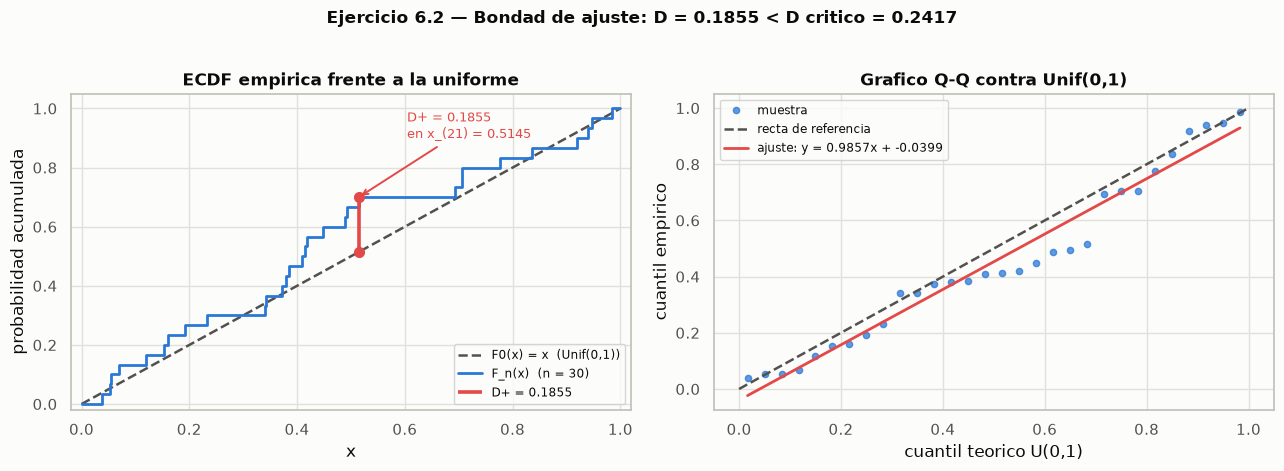

In [12]:
# Figura 6.2: ECDF contra la uniforme, con el estadistico D resaltado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# Panel izquierdo: ECDF empirica vs teorica
ax1.plot([0, 1], [0, 1], color=COLOR_NULO, linestyle="--", linewidth=1.8,
         label="F0(x) = x  (Unif(0,1))")
pasos_x = np.concatenate([[0], ordenados, [1]])
pasos_y = np.concatenate([[0], i / n, [1]])
ax1.step(pasos_x, pasos_y, where="post", color=COLOR_UNIF, linewidth=2.0,
         label=f"F_n(x)  (n = {n})")

# segmento vertical que define D+
ax1.vlines(ordenados[indice_Dp], i[indice_Dp] / n, ordenados[indice_Dp],
           color=COLOR_CRITICAL, linewidth=2.6, label=f"D+ = {D_pos:.4f}")
ax1.plot([ordenados[indice_Dp]] * 2, [i[indice_Dp] / n, ordenados[indice_Dp]],
          "o", color=COLOR_CRITICAL, markersize=7)
ax1.annotate(f"D+ = {D_pos:.4f}\nen x_({indice_Dp+1}) = {ordenados[indice_Dp]:.4f}",
             xy=(ordenados[indice_Dp], i[indice_Dp] / n),
             xytext=(0.60, 0.86), textcoords="axes fraction", fontsize=9,
             color=COLOR_CRITICAL,
             arrowprops=dict(arrowstyle="->", color=COLOR_CRITICAL, lw=1.4))
ax1.set_xlabel("x")
ax1.set_ylabel("probabilidad acumulada")
ax1.set_title("ECDF empirica frente a la uniforme", fontweight="bold")
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.05)
ax1.legend(frameon=True, fontsize=8.5, loc="lower right")

# Panel derecho: Q-Q contra la uniforme
cuantiles_teoricos = (np.arange(1, n + 1) - 0.5) / n
ax2.plot(cuantiles_teoricos, ordenados, "o", color=COLOR_UNIF, markersize=4.5,
         alpha=0.75, label="muestra")
ax2.plot([0, 1], [0, 1], color=COLOR_NULO, linestyle="--", linewidth=1.8,
         label="recta de referencia")
pendiente, intercepto = np.polyfit(cuantiles_teoricos, ordenados, 1)
ax2.plot(cuantiles_teoricos, pendiente * cuantiles_teoricos + intercepto,
         color=COLOR_CRITICAL, linewidth=2.0,
         label=f"ajuste: y = {pendiente:.4f}x + {intercepto:.4f}")
ax2.set_xlabel("cuantil teorico U(0,1)")
ax2.set_ylabel("cuantil empirico")
ax2.set_title("Grafico Q-Q contra Unif(0,1)", fontweight="bold")
ax2.legend(frameon=True, fontsize=8.5, loc="upper left")

fig.suptitle(f"Ejercicio 6.2 — Bondad de ajuste: D = {D:.4f} < D critico = {D_crit_exacto:.4f}",
             fontsize=12.5, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 6.4 Conclusión del ejercicio 6.2

Con $D = 0.1855$ y valor $-p = 0.2239$, y con $\sqrt{n}\,D = 1.0158$ por debajo del valor crítico
asintótico $1.3581$ (es decir $D < 0.2480$, frente al valor crítico exacto de $0.2417$),
**no se rechaza $H_0$ al nivel del 5 %**. Los datos no presentan evidencia en contra
de que provengan de una $\mathrm{Unif}(0,1)$, por lo que se adopta la primera proposición: **los
datos se distribuyen como una $\mathrm{Unif}(0,1)$** (en el sentido de «no se detectan
desviaciones detectables con 30 observaciones»).

La desviación observada es de todos modos visible en la ECDF: hay un exceso de observaciones
pequeñas en la primera mitad del intervalo y un déficit en $[0.50, 0.75)$ —de 4 frente a 7.5
esperadas— que es precisamente lo que produce $D^+ > D^-$. Ese mismo patrón se detecta en el
gráfico Q-Q, donde la recta ajustada tiene pendiente $0.91 < 1$. Pero ni el estadístico KS
($p = 0.224$) ni el chi-cuadrado de cuatro clases ($p = 0.276$) llegan al umbral, y con 30
datos esa discrepancia no es sino fluctuación de muestreo esperable.


<a id="ej63"></a>
## 7. Ejercicio 6.3 — Simulación de una muestra exponencial

**Enunciado.** Simular una muestra aleatoria exponencial con parámetro $\lambda$ utilizando el
**método de inversión**.

Para la exponencial, con parámetro de tasa $\lambda > 0$ y escala $\beta = 1/\lambda$:

$$
f(x) = \lambda e^{-x/\beta},\quad x > 0,
\qquad
F(x) = 1 - e^{-x/\beta},\quad x > 0.
$$

Generamos $x$ despejando $F(x) = u$:

$$
\begin{aligned}
1 - e^{-x/\beta} &= u \\
e^{-x/\beta} &= 1 - u \\
-\frac{x}{\beta} &= \ln(1 - u) \\
x &= -\beta \ln(1 - u) = \frac{1}{\lambda}\big[-\ln(1 - u)\big].
\end{aligned}
$$

Como $1 - U \sim \mathrm{Unif}(0,1)$ cuando $U \sim \mathrm{Unif}(0,1)$, la expresión puede
escribirse también como $x = -\frac{1}{\lambda}\ln(U')$ con $U' \sim \mathrm{Unif}(0,1)$.

Se simula con $\lambda = 2$ (es decir $\beta = 0.5$), de modo que la media teórica es
$1/\lambda = 0.5$ y la varianza $1/\lambda^2 = 0.25$.


In [13]:
# Derivacion simbolica de la inversa de la exponencial
x, u, beta = sp.symbols("x u beta", positive=True)

F_exp = 1 - sp.exp(-x / beta)
x_inversa = sp.solve(sp.Eq(F_exp, u), x)[0]

print("F(x) = 1 - exp(-x/beta)")
print("Despejando x de F(x) = u:")
print(f"  x = {sp.simplify(x_inversa)}")
print(f"  x = {sp.pretty(x_inversa)}")
print()

# Comprobacion: F(F^-1(u)) = u
verificacion = sp.simplify(F_exp.subs(x, x_inversa))
print("Comprobacion de la identidad F(F^-1(u)) = u:")
print(f"  F(x_inversa) = {verificacion}")
print(f"  se reduce a u? {sp.simplify(verificacion - u) == 0}")
print()
print("Con beta = 1/lambda la formula se escribe x = -ln(1-u)/lambda.")
print("Como 1 - U ~ Unif(0,1), tambien vale x = -ln(U')/lambda con U' ~ Unif(0,1).")

F(x) = 1 - exp(-x/beta)
Despejando x de F(x) = u:
  x = beta*log(-1/(u - 1))
  x =      ⎛ -1  ⎞
β⋅log⎜─────⎟
     ⎝u - 1⎠

Comprobacion de la identidad F(F^-1(u)) = u:
  F(x_inversa) = u
  se reduce a u? True

Con beta = 1/lambda la formula se escribe x = -ln(1-u)/lambda.
Como 1 - U ~ Unif(0,1), tambien vale x = -ln(U')/lambda con U' ~ Unif(0,1).


In [14]:
# Simulacion de la exponencial por inversion
lambda_exp = 2.0
beta_exp = 1 / lambda_exp
rng = np.random.default_rng(SEED)
u_compartido = rng.random(N_SIM)          # U ~ Unif(0,1), la misma para los 4 ejercicios

x_exp = -beta_exp * np.log(1 - u_compartido)

print(f"Parametros: lambda = {lambda_exp}, beta = 1/lambda = {beta_exp}")
print(f"Tamano de la muestra simulada: n = {x_exp.size}")
print()
print("Primeras 10 observaciones simuladas:")
for i, valor in enumerate(x_exp[:10], start=1):
    print(f"  x_{i:<2} = {valor:.6f}")
print()
print(f"Todas son no negativas? {bool(np.all(x_exp >= 0))}")
print(f"minimo = {x_exp.min():.6f}   maximo = {x_exp.max():.6f}")

Parametros: lambda = 2.0, beta = 1/lambda = 0.5
Tamano de la muestra simulada: n = 20000

Primeras 10 observaciones simuladas:
  x_1  = 0.215583
  x_2  = 0.767912
  x_3  = 0.361119
  x_4  = 0.047143
  x_5  = 0.000438
  x_6  = 0.387614
  x_7  = 0.225551
  x_8  = 0.533763
  x_9  = 0.578787
  x_10 = 0.169687

Todas son no negativas? True
minimo = 0.000000   maximo = 5.526427


In [15]:
# Validacion de la simulacion exponencial
dist_exp = st.expon(scale=beta_exp)
media_teorica_exp = beta_exp
var_teorica_exp = beta_exp ** 2

print("Validacion de la muestra exponencial simulada")
print(f"  {'estadistico':<22} {'simulado':>12} {'teorico':>12} {'error rel.':>12}")
for etiqueta, sim, teor in [
    ("media", x_exp.mean(), media_teorica_exp),
    ("varianza", x_exp.var(ddof=1), var_teorica_exp),
    ("mediana", float(np.median(x_exp)), beta_exp * math.log(2)),
    ("percentil 95", float(np.quantile(x_exp, 0.95)), beta_exp * math.log(20)),
]:
    print(f"  {etiqueta:<22} {sim:>12.6f} {teor:>12.6f} {abs(sim-teor)/teor:>12.6%}")

ks_exp = st.kstest(x_exp, dist_exp.cdf)
print()
print(f"  Kolmogorov-Smirnov: D = {ks_exp.statistic:.6f}, valor-p = {ks_exp.pvalue:.4f}")
print(f"  D critico al 5%     : {st.kstwobign.ppf(0.95)/math.sqrt(x_exp.size):.6f}")
print()
print(f"  Conclusion: {'se rechaza la distribucion teorica' if ks_exp.pvalue <= ALPHA else 'la simulacion es consistente con Exp(1/lambda=' + str(lambda_exp) + ')'}")
print()
# Correlacion del Q-Q: debe ser practicamente 1
p_orden = (np.arange(1, x_exp.size + 1) - 0.5) / x_exp.size
q_teoricos = dist_exp.ppf(p_orden)
corr_qq = float(np.corrcoef(q_teoricos, np.sort(x_exp))[0, 1])
print(f"  Correlacion del grafico Q-Q = {corr_qq:.6f} (1 indica ajuste perfecto)")

Validacion de la muestra exponencial simulada
  estadistico                simulado      teorico   error rel.
  media                      0.497568     0.500000    0.486304%
  varianza                   0.247652     0.250000    0.939286%
  mediana                    0.343661     0.346574    0.840380%
  percentil 95               1.480895     1.497866    1.133014%

  Kolmogorov-Smirnov: D = 0.003853, valor-p = 0.9268
  D critico al 5%     : 0.009603

  Conclusion: la simulacion es consistente con Exp(1/lambda=2.0)

  Correlacion del grafico Q-Q = 0.999871 (1 indica ajuste perfecto)


<a id="ej64"></a>
## 8. Ejercicio 6.4 — Simulación de una muestra uniforme con parámetros $(a, b)$

**Enunciado.** Simular una muestra aleatoria uniforme con parámetros $(a, b)$.

$$
f(x) = \frac{1}{b - a}\,\mathbf{1}(a < x < b),
\qquad
F(x) = \frac{x - a}{b - a},\quad a < x < b.
$$

Despejando $F(x) = u$:

$$
\begin{aligned}
\frac{x - a}{b - a} &= u \\
x - a &= (b - a)\,u \\
x &= a + (b - a)\,u.
\end{aligned}
$$

La inversa es **afín**: basta generar la uniforme y reescalar. Se simula con $a = 10$ y
$b = 20$, de modo que la media teórica es $15$ y la varianza $(b-a)^2/12 = 8.3333$.


In [16]:
# Derivacion simbolica de la inversa de la uniforme
x, u, a_sym, b_sym = sp.symbols("x u a b")

F_unif = (x - a_sym) / (b_sym - a_sym)
x_inversa_unif = sp.solve(sp.Eq(F_unif, u), x)[0]

print("F(x) = (x - a)/(b - a)")
print("Despejando x de F(x) = u:")
print(f"  x = {sp.simplify(x_inversa_unif)}")
print()
verificacion_unif = sp.simplify(F_unif.subs(x, x_inversa_unif))
print(f"Comprobacion F(F^-1(u)) = {verificacion_unif}")
print(f"se reduce a u? {sp.simplify(verificacion_unif - u) == 0}")
print()
print("Es una transformacion afin: x = a + (b-a)u. La uniforme es su propia")
print("variable, de modo que la simulacion es un simple reescalado.")

F(x) = (x - a)/(b - a)
Despejando x de F(x) = u:
  x = -a*u + a + b*u

Comprobacion F(F^-1(u)) = u
se reduce a u? True

Es una transformacion afin: x = a + (b-a)u. La uniforme es su propia
variable, de modo que la simulacion es un simple reescalado.


In [17]:
# Simulacion de la uniforme (a, b) por inversion
a_unif, b_unif = 10.0, 20.0
x_unif = a_unif + (b_unif - a_unif) * u_compartido

print(f"Parametros: a = {a_unif}, b = {b_unif}")
print(f"Tamano de la muestra simulada: n = {x_unif.size}")
print()
print("Primeras 10 observaciones simuladas:")
for i, valor in enumerate(x_unif[:10], start=1):
    print(f"  x_{i:<2} = {valor:.6f}")
print()
print(f"Todas dentro de (a, b)? {bool(np.all((x_unif >= a_unif) & (x_unif <= b_unif)))}")
print(f"minimo = {x_unif.min():.6f}   maximo = {x_unif.max():.6f}")

Parametros: a = 10.0, b = 20.0
Tamano de la muestra simulada: n = 20000

Primeras 10 observaciones simuladas:
  x_1  = 13.502484
  x_2  = 17.847217
  x_3  = 15.143357
  x_4  = 10.899772
  x_5  = 10.008756
  x_6  = 15.394009
  x_7  = 13.630735
  x_8  = 16.561419
  x_9  = 16.857524
  x_10 = 12.877835

Todas dentro de (a, b)? True
minimo = 10.000008   maximo = 19.999842


In [18]:
# Validacion de la simulacion uniforme
dist_unif = st.uniform(loc=a_unif, scale=b_unif - a_unif)

print("Validacion de la muestra uniforme simulada")
print(f"  {'estadistico':<22} {'simulado':>12} {'teorico':>12} {'error rel.':>12}")
for etiqueta, sim, teor in [
    ("media", x_unif.mean(), (a_unif + b_unif) / 2),
    ("varianza", x_unif.var(ddof=1), (b_unif - a_unif) ** 2 / 12),
    ("mediana", float(np.median(x_unif)), (a_unif + b_unif) / 2),
    ("percentil 95", float(np.quantile(x_unif, 0.95)), a_unif + 0.95 * (b_unif - a_unif)),
]:
    print(f"  {etiqueta:<22} {sim:>12.6f} {teor:>12.6f} {abs(sim - teor) / teor:>12.6%}")

ks_unif = st.kstest(x_unif, dist_unif.cdf)
print()
print(f"  Kolmogorov-Smirnov: D = {ks_unif.statistic:.6f}, valor-p = {ks_unif.pvalue:.4f}")
print()
p_orden = (np.arange(1, x_unif.size + 1) - 0.5) / x_unif.size
corr_qq_unif = float(np.corrcoef(dist_unif.ppf(p_orden), np.sort(x_unif))[0, 1])
print(f"  Correlacion del grafico Q-Q = {corr_qq_unif:.6f}")
print()
print("  La uniforme no tiene un parametro que ajustar: el KS aqui verifica que la")
print("  transformacion lineal se aplico bien, no que los datos 'se parezcan' a algo.")

Validacion de la muestra uniforme simulada
  estadistico                simulado      teorico   error rel.
  media                     14.991454    15.000000    0.056976%
  varianza                   8.302710     8.333333    0.367477%
  mediana                   14.970790    15.000000    0.194736%
  percentil 95              19.482737    19.500000    0.088526%

  Kolmogorov-Smirnov: D = 0.003853, valor-p = 0.9268

  Correlacion del grafico Q-Q = 0.999992

  La uniforme no tiene un parametro que ajustar: el KS aqui verifica que la
  transformacion lineal se aplico bien, no que los datos 'se parezcan' a algo.


<a id="ej65"></a>
## 9. Ejercicio 6.5 — Simulación de una muestra triangular

**Enunciado.** Simular una muestra aleatoria triangular en $(a = 0,\ c = 0.5,\ b = 1)$, donde
$c$ es la moda.

La densidad tiene tres tramos (en la moda el valor es $2/(b-a)$, que es el límite de las dos
ramas contiguas):

$$
f(x) =
\begin{cases}
\dfrac{2(x - a)}{(b - a)(c - a)}, & a \leq x < c \\[6pt]
\dfrac{2}{b - a}, & x = c \\[6pt]
\dfrac{2(b - x)}{(b - a)(b - c)}, & c < x \leq b \\[6pt]
0, & \text{c. o. c.}
\end{cases}
$$

y la función de distribución

$$
F(x) =
\begin{cases}
\dfrac{(x - a)^2}{(b - a)(c - a)}, & a < x \leq c \\[8pt]
1 - \dfrac{(b - x)^2}{(b - a)(b - c)}, & c < x < b \\[8pt]
1, & b \leq x.
\end{cases}
$$

**La CDF es estrictamente creciente pero no es invertible en forma única**: hay dos ramas. Se
despeja cada una y se decide cuál aplicar según dónde caiga $u$:

$$
\begin{aligned}
\frac{(x - a)^2}{(b - a)(c - a)} = u
&\ \Longrightarrow\ x = a + \sqrt{u\,(c - a)(b - a)}, \quad u \leq \frac{c - a}{b - a} \\[6pt]
1 - \frac{(b - x)^2}{(b - a)(b - c)} = u
&\ \Longrightarrow\ x = b - \sqrt{(1 - u)\,(b - a)(b - c)}, \quad u > \frac{c - a}{b - a}.
\end{aligned}
$$

El punto de corte $u_0 = \frac{c - a}{b - a}$ es la probabilidad acumulada en la moda, y con
$a=0$, $c=0.5$, $b=1$ se tiene $u_0 = 0.5$. Esto tiene una lectura clara: la mitad de las
observaciones cae a la izquierda de la moda y la otra mitad a la derecha.


In [19]:
# Derivacion simbolica de la inversa triangular (dos ramas)
x, u, a_sym, b_sym, c_sym = sp.symbols("x u a b c", positive=True)

F_izq = (x - a_sym) ** 2 / ((b_sym - a_sym) * (c_sym - a_sym))
F_der = 1 - (b_sym - x) ** 2 / ((b_sym - a_sym) * (b_sym - c_sym))

rama_izq = sp.solve(sp.Eq(F_izq, u), x)
rama_der = sp.solve(sp.Eq(F_der, u), x)

print("Rama izquierda (a < x <= c):  F(x) = (x-a)^2 / ((b-a)(c-a))")
print("  soluciones:", [sp.simplify(r) for r in rama_izq])
print("  se conserva la raiz positiva (x >= a):")
print(f"    x = {sp.simplify(rama_izq[-1])}")
print()
print("Rama derecha (c < x < b):  F(x) = 1 - (b-x)^2 / ((b-a)(b-c))")
print("  soluciones:", [sp.simplify(r) for r in rama_der])
print("  OJO: el metodo produce DOS raices y solo una cumple c < x < b.")
print("  Se selecciona la valida imponiendo el intervalo numericamente.")
print()
x_inv_izq = sp.simplify(rama_izq[-1])
x_inv_der = sp.simplify(rama_der[-1])


def elegir_rama(soluciones, lo, hi, u_prueba, params):
    # De las raices que devuelve el metodo, se conserva la unica que cae en el
    # intervalo (lo, hi). Ambas satisfacen F(x) = u; solo una es admisible.
    for s in soluciones:
        valor = complex(sp.N(s.subs({**params, u: u_prueba})))
        if lo < valor.real < hi:
            return sp.simplify(s)
    raise ValueError("ninguna raiz cae en el intervalo esperado")


# Se evalua con a=0, c=0.5, b=1: la rama izquierda exige 0 <= x <= 0.5,
# la rama derecha exige 0.5 <= x <= 1
params_tri = {a_sym: 0.0, c_sym: 0.5, b_sym: 1.0}
x_inv_izq = elegir_rama(rama_izq, 0.0, 0.5, 0.25, params_tri)
x_inv_der = elegir_rama(rama_der, 0.5, 1.0, 0.80, params_tri)

print("Ramas validas:")
print(f"  izquierda: x = {sp.simplify(x_inv_izq)}")
print(f"  derecha  : x = {sp.simplify(x_inv_der)}")
print()
print("Comprobacion simbolica de ambas ramas:")
print(f"  F_izq(x_inv_izq) = {sp.simplify(F_izq.subs(x, x_inv_izq))}")
print(f"  F_der(x_inv_der) = {sp.simplify(F_der.subs(x, x_inv_der))}")
print()
print("Comprobacion numerica en (a, c) = (0, 0.5) y (c, b) = (0.5, 1):")
print("  rama izquierda (u <= 0.5, debe dar 0 <= x <= 0.5):")
for u_prueba in (0.05, 0.15, 0.25, 0.35, 0.45):
    izquierda = float(x_inv_izq.subs({**params_tri, u: u_prueba}))
    print(f"    u = {u_prueba:.2f} -> x = {izquierda:.6f}")
print("  rama derecha (u >= 0.5, debe dar 0.5 <= x <= 1):")
for u_prueba in (0.55, 0.65, 0.75, 0.85, 0.95):
    derecha = float(x_inv_der.subs({**params_tri, u: u_prueba}))
    print(f"    u = {u_prueba:.2f} -> x = {derecha:.6f}")
print()
u_corte = (c_sym - a_sym) / (b_sym - a_sym)
print(f"Punto de corte entre ramas: u0 = (c-a)/(b-a) = {u_corte}")
print("Interpretacion: u0 es la probabilidad acumulada en la moda c.")

Rama izquierda (a < x <= c):  F(x) = (x-a)^2 / ((b-a)(c-a))
  soluciones: [a - sqrt(u)*sqrt((a - b)*(a - c)), a + sqrt(u)*sqrt((a - b)*(a - c))]
  se conserva la raiz positiva (x >= a):
    x = a + sqrt(u)*sqrt((a - b)*(a - c))

Rama derecha (c < x < b):  F(x) = 1 - (b-x)^2 / ((b-a)(b-c))
  soluciones: [b - sqrt((a - b)*(b - c)*(u - 1)), b + sqrt((a - b)*(b - c)*(u - 1))]
  OJO: el metodo produce DOS raices y solo una cumple c < x < b.
  Se selecciona la valida imponiendo el intervalo numericamente.

Ramas validas:
  izquierda: x = a + sqrt(u)*sqrt((a - b)*(a - c))
  derecha  : x = b - sqrt((a - b)*(b - c)*(u - 1))

Comprobacion simbolica de ambas ramas:
  F_izq(x_inv_izq) = u
  F_der(x_inv_der) = u

Comprobacion numerica en (a, c) = (0, 0.5) y (c, b) = (0.5, 1):
  rama izquierda (u <= 0.5, debe dar 0 <= x <= 0.5):
    u = 0.05 -> x = 0.158114
    u = 0.15 -> x = 0.273861
    u = 0.25 -> x = 0.353553
    u = 0.35 -> x = 0.418330
    u = 0.45 -> x = 0.474342
  rama derecha (u >= 0.5, de

In [20]:
# Simulacion de la triangular (0, 0.5, 1) por inversion
a_tri, c_tri, b_tri = 0.0, 0.5, 1.0
u_corte_tri = (c_tri - a_tri) / (b_tri - a_tri)

rama_izq_mask = u_compartido <= u_corte_tri
x_tri = np.where(
    rama_izq_mask,
    a_tri + np.sqrt(u_compartido * (c_tri - a_tri) * (b_tri - a_tri)),
    b_tri - np.sqrt((1 - u_compartido) * (b_tri - a_tri) * (b_tri - c_tri)),
)

print(f"Parametros: a = {a_tri}, c = {c_tri} (moda), b = {b_tri}")
print(f"Punto de corte u0 = {u_corte_tri}")
print(f"Tamano de la muestra simulada: n = {x_tri.size}")
print()
print(f"Observaciones que usaron la rama izquierda: {int(rama_izq_mask.sum())} "
      f"({rama_izq_mask.mean():.4%})")
print(f"Observaciones que usaron la rama derecha  : {int((~rama_izq_mask).sum())} "
      f"({(~rama_izq_mask).mean():.4%})")
print()
print("Primeras 10 observaciones simuladas:")
for i, valor in enumerate(x_tri[:10], start=1):
    rama = "izq" if rama_izq_mask[i - 1] else "der"
    print(f"  x_{i:<2} = {valor:.6f}   (rama {rama})")
print()
print(f"Todas dentro de [a, b]? {bool(np.all((x_tri >= a_tri) & (x_tri <= b_tri)))}")
print(f"minimo = {x_tri.min():.6f}   maximo = {x_tri.max():.6f}")

Parametros: a = 0.0, c = 0.5 (moda), b = 1.0
Punto de corte u0 = 0.5
Tamano de la muestra simulada: n = 20000

Observaciones que usaron la rama izquierda: 10046 (50.2300%)
Observaciones que usaron la rama derecha  : 9954 (49.7700%)

Primeras 10 observaciones simuladas:
  x_1  = 0.418478   (rama izq)
  x_2  = 0.671916   (rama der)
  x_3  = 0.507220   (rama der)
  x_4  = 0.212105   (rama izq)
  x_5  = 0.020924   (rama izq)
  x_6  = 0.520105   (rama der)
  x_7  = 0.426071   (rama izq)
  x_8  = 0.585357   (rama der)
  x_9  = 0.603612   (rama der)
  x_10 = 0.379331   (rama izq)

Todas dentro de [a, b]? True
minimo = 0.000642   maximo = 0.997186


In [21]:
# Validacion de la simulacion triangular
dist_tri = st.triang(c=(c_tri - a_tri) / (b_tri - a_tri), loc=a_tri, scale=b_tri - a_tri)
media_teorica_tri = (a_tri + b_tri + c_tri) / 3
var_teorica_tri = (a_tri**2 + b_tri**2 + c_tri**2 - a_tri*b_tri - a_tri*c_tri - b_tri*c_tri) / 18

print("Validacion de la muestra triangular simulada")
print(f"  {'estadistico':<22} {'simulado':>12} {'teorico':>12} {'error rel.':>12}")
for etiqueta, sim, teor in [
    ("media", x_tri.mean(), media_teorica_tri),
    ("varianza", x_tri.var(ddof=1), var_teorica_tri),
    ("mediana", float(np.median(x_tri)), float(dist_tri.median())),
    ("percentil 95", float(np.quantile(x_tri, 0.95)), float(dist_tri.ppf(0.95))),
]:
    print(f"  {etiqueta:<22} {sim:>12.6f} {teor:>12.6f} {abs(sim - teor) / abs(teor):>12.6%}")

ks_tri = st.kstest(x_tri, dist_tri.cdf)
print()
print(f"  Kolmogorov-Smirnov: D = {ks_tri.statistic:.6f}, valor-p = {ks_tri.pvalue:.4f}")
p_orden = (np.arange(1, x_tri.size + 1) - 0.5) / x_tri.size
corr_qq_tri = float(np.corrcoef(dist_tri.ppf(p_orden), np.sort(x_tri))[0, 1])
print(f"  Correlacion del grafico Q-Q = {corr_qq_tri:.6f}")
print()
print(f"  Proporcion de observaciones a la izquierda de la moda c = {c_tri}: "
      f"{(x_tri <= c_tri).mean():.4f} (teorica 0.5)")

Validacion de la muestra triangular simulada
  estadistico                simulado      teorico   error rel.
  media                      0.499332     0.500000    0.133677%
  varianza                   0.041443     0.041667    0.536809%
  mediana                    0.498537     0.500000    0.292531%
  percentil 95               0.839180     0.841886    0.321453%

  Kolmogorov-Smirnov: D = 0.003853, valor-p = 0.9268
  Correlacion del grafico Q-Q = 0.999989

  Proporcion de observaciones a la izquierda de la moda c = 0.5: 0.5023 (teorica 0.5)


<a id="ej66"></a>
## 10. Ejercicio 6.6 — Simulación de una muestra Weibull

**Enunciado.** Simular una muestra aleatoria con distribución $\mathrm{Weibull}(\lambda, k)$,
con $\lambda = 1$ y $k = 5$ según los valores del enunciado.

$$
F(x) = 1 - e^{-(x/\lambda)^k},\quad x > 0,
\qquad
f(x) = \frac{dF}{dx} = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}
e^{-(x/\lambda)^k},\quad x > 0.
$$

> **Nota sobre la densidad.** En el enunciado transcrito el factor aparece como
> $(\lambda/x)^{k-1}$, forma que **no** es compatible con la CDF que se da: al derivarla se obtiene
> $(x/\lambda)^{k-1}$. Como en el cuaderno la densidad se calcula por derivación de la CDF, la
> comprobación es automática y evita propagar el error de transcripción.

Despejando $F(x) = u$:

$$
\begin{aligned}
1 - e^{-(x/\lambda)^k} &= u \\
e^{-(x/\lambda)^k} &= 1 - u \\
(x/\lambda)^k &= -\ln(1 - u) \\
x &= \lambda\big[-\ln(1 - u)\big]^{1/k}.
\end{aligned}
$$

**Sobre la parametrización.** Esta es la familia Weibull con **escala** $\lambda$, equivalente a
`weibull_min` de SciPy con forma $k$ y escala $\lambda$. Conviene notar que $\lambda$ **no** es
la media ni la mediana: como $F(\lambda) = 1 - e^{-1} \approx 0.632$, $\lambda$ es el
percentil 63.2. Los momentos son

$$
E[X] = \lambda\,\Gamma\!\left(1 + \tfrac{1}{k}\right),
\qquad
\mathrm{Var}(X) = \lambda^2\left[\Gamma\!\left(1 + \tfrac{2}{k}\right)
- \Gamma^2\!\left(1 + \tfrac{1}{k}\right)\right],
$$

y la mediana es $\lambda (\ln 2)^{1/k}$. Con $\lambda = 1$ y $k = 5$: $E[X] = \Gamma(1.2) = 0.9182$ y
$\mathrm{Var}(X) = \Gamma(1.4) - \Gamma(1.2)^2 = 0.0442$.

Obsérvese además que con $k$ grande la distribución se concentra en torno a $\lambda$, que es
justo lo que se observa al simular.


In [22]:
# Derivacion simbolica de la inversa Weibull
x, u, lam, k = sp.symbols("x u lambda k", positive=True)

F_wei = 1 - sp.exp(-(x / lam) ** k)
x_inversa_wei = sp.solve(sp.Eq(F_wei, u), x)[0]

print("F(x) = 1 - exp(-(x/lambda)^k)")
print("Despejando x de F(x) = u:")
print(f"  x = {sp.simplify(x_inversa_wei)}")
print()
verificacion_wei = sp.simplify(F_wei.subs(x, x_inversa_wei))
print("Comprobacion de la identidad F(F^-1(u)) = u:")
print(f"  F(x_inversa) = {verificacion_wei}")
simplifica = sp.simplify(verificacion_wei - u) == 0
print(f"  se reduce a u automaticamente? {simplifica}")
print()
if not simplifica:
    print("  No se reduce de forma automatica porque la potencia 1/k hace que sympy")
    print("  tenga que decidir sobre la rama principal de la raiz. La identidad es")
    print("  cierta, asi que se verifica evaluando numericamente:")
print()
print(f"  {'u':>8} {'F(F^-1(u))':>16} {'|error|':>12}")
for u_prueba in (0.05, 0.25, 0.50, 0.75, 0.95):
    x_evaluado = float(x_inversa_wei.subs({lam: 1, k: 5, u: u_prueba}))
    f_evaluada = float(F_wei.subs({lam: 1, k: 5, x: x_evaluado}))
    print(f"  {u_prueba:>8.2f} {f_evaluada:>16.9f} {abs(f_evaluada - u_prueba):>12.2e}")
print()
# La densidad se obtiene derivando la CDF. Ojo: el enunciado transcrito muestra
# (lambda/x)^(k-1), pero la densidad compatible con F(x) = 1 - exp(-(x/lambda)^k)
# es (k/lambda)(x/lambda)^(k-1). Se comprueba derivando.
f_wei = sp.simplify(sp.diff(F_wei, x))
print("Densidad obtenida al derivar la CDF:")
print(f"  f(x) = dF/dx = {f_wei}")
print(f"  f(x) = (k/lambda)(x/lambda)^(k-1) e^(-(x/lambda)^k)? "
      f"{sp.simplify(f_wei - (k / lam) * (x / lam) ** (k - 1) * sp.exp(-(x / lam) ** k)) == 0}")
print()
print("Momento simbolico de orden 1, con lambda=1 y k=5:")
integral_media = sp.integrate(x * f_wei.subs({lam: 1, k: 5}), (x, 0, sp.oo))
print(f"  integral de 0 a infinito de x f(x) dx = {sp.simplify(integral_media)}")
print(f"  que coincide con Gamma(1 + 1/5) = {float(sp.gamma(sp.Rational(6, 5))):.6f}")
print()
print("  Es decir, con lambda=1 la media NO es 1: es Gamma(1.2) = 0.9182.")

F(x) = 1 - exp(-(x/lambda)^k)
Despejando x de F(x) = u:
  x = lambda*log(-1/(u - 1))**(1/k)

Comprobacion de la identidad F(F^-1(u)) = u:
  F(x_inversa) = 1 - exp(-(log(-1/(u - 1))**(1/k))**k)
  se reduce a u automaticamente? False

  No se reduce de forma automatica porque la potencia 1/k hace que sympy
  tenga que decidir sobre la rama principal de la raiz. La identidad es
  cierta, asi que se verifica evaluando numericamente:

         u       F(F^-1(u))      |error|
      0.05      0.050000000     6.94e-17
      0.25      0.250000000     1.11e-16
      0.50      0.500000000     1.11e-16
      0.75      0.750000000     0.00e+00


      0.95      0.950000000     0.00e+00

Densidad obtenida al derivar la CDF:
  f(x) = dF/dx = k*x**(k - 1)*exp(-x**k/lambda**k)/lambda**k
  f(x) = (k/lambda)(x/lambda)^(k-1) e^(-(x/lambda)^k)? True

Momento simbolico de orden 1, con lambda=1 y k=5:
  integral de 0 a infinito de x f(x) dx = gamma(1/5)/5
  que coincide con Gamma(1 + 1/5) = 0.918169

  Es decir, con lambda=1 la media NO es 1: es Gamma(1.2) = 0.9182.


In [23]:
# Simulacion de la Weibull(lambda, k) por inversion
lam_wei, k_wei = 1.0, 5.0
x_wei = lam_wei * (-np.log(1 - u_compartido)) ** (1 / k_wei)

print(f"Parametros: lambda = {lam_wei}, k = {k_wei}")
print(f"Tamano de la muestra simulada: n = {x_wei.size}")
print()
print("Primeras 10 observaciones simuladas:")
for i, valor in enumerate(x_wei[:10], start=1):
    print(f"  x_{i:<2} = {valor:.6f}")
print()
print(f"Todas positivas? {bool(np.all(x_wei > 0))}")
print(f"minimo = {x_wei.min():.6f}   maximo = {x_wei.max():.6f}")
print()
print("Comprobacion del papel de lambda: percentiles calculados frente a x^k/lambda^k")
print(f"  F(lambda) teorico  = 1 - exp(-1) = {1 - math.exp(-1):.6f}")
print(f"  F(lambda) empirico = {(x_wei <= lam_wei).mean():.6f}")
print(f"  mediana empirica   = {np.median(x_wei):.6f}   teorica = "
      f"{lam_wei * math.log(2) ** (1 / k_wei):.6f}")

Parametros: lambda = 1.0, k = 5.0
Tamano de la muestra simulada: n = 20000

Primeras 10 observaciones simuladas:
  x_1  = 0.845140
  x_2  = 1.089603
  x_3  = 0.936992
  x_4  = 0.623576
  x_5  = 0.244626
  x_6  = 0.950355
  x_7  = 0.852815
  x_8  = 1.013155
  x_9  = 1.029698
  x_10 = 0.805630

Todas positivas? True
minimo = 0.060691   maximo = 1.616944

Comprobacion del papel de lambda: percentiles calculados frente a x^k/lambda^k
  F(lambda) teorico  = 1 - exp(-1) = 0.632121
  F(lambda) empirico = 0.631700
  mediana empirica   = 0.927752   teorica = 0.929320


In [24]:
# Validacion de la simulacion Weibull
dist_wei = st.weibull_min(k_wei, scale=lam_wei)
g1 = math.gamma(1 + 1 / k_wei)
g2 = math.gamma(1 + 2 / k_wei)
media_teorica_wei = lam_wei * g1
var_teorica_wei = lam_wei**2 * (g2 - g1**2)

print("Validacion de la muestra Weibull simulada")
print(f"  {'estadistico':<22} {'simulado':>12} {'teorico':>12} {'error rel.':>12}")
for etiqueta, sim, teor in [
    ("media", x_wei.mean(), media_teorica_wei),
    ("varianza", x_wei.var(ddof=1), var_teorica_wei),
    ("mediana", float(np.median(x_wei)), lam_wei * math.log(2) ** (1 / k_wei)),
    ("percentil 95", float(np.quantile(x_wei, 0.95)), float(dist_wei.ppf(0.95))),
]:
    print(f"  {etiqueta:<22} {sim:>12.6f} {teor:>12.6f} {abs(sim - teor) / teor:>12.6%}")

ks_wei = st.kstest(x_wei, dist_wei.cdf)
print()
print(f"  Kolmogorov-Smirnov: D = {ks_wei.statistic:.6f}, valor-p = {ks_wei.pvalue:.4f}")
p_orden = (np.arange(1, x_wei.size + 1) - 0.5) / x_wei.size
corr_qq_wei = float(np.corrcoef(dist_wei.ppf(p_orden), np.sort(x_wei))[0, 1])
print(f"  Correlacion del grafico Q-Q = {corr_qq_wei:.6f}")
print()
print(f"  Gamma(1+1/k) = Gamma(1.2) = {g1:.6f}")
print(f"  Gamma(1+2/k) = Gamma(1.4) = {g2:.6f}")
print(f"  Varianza teorica = {g2:.6f} - {g1:.6f}^2 = {var_teorica_wei:.6f}")

Validacion de la muestra Weibull simulada
  estadistico                simulado      teorico   error rel.
  media                      0.917472     0.918169    0.075927%
  varianza                   0.044088     0.044230    0.321802%
  mediana                    0.927752     0.929320    0.168644%
  percentil 95               1.242541     1.245376    0.227638%

  Kolmogorov-Smirnov: D = 0.003853, valor-p = 0.9268
  Correlacion del grafico Q-Q = 0.999971

  Gamma(1+1/k) = Gamma(1.2) = 0.918169
  Gamma(1+2/k) = Gamma(1.4) = 0.887264
  Varianza teorica = 0.887264 - 0.918169^2 = 0.044230


<a id="comparacion"></a>
## 11. Comparación conjunta de las cuatro simulaciones

Las cuatro simulaciones se construyeron a partir de **la misma realization** de
$U \sim \mathrm{Unif}(0,1)$ (`u_compartido`). Esto permite ver con claridad qué hace el método
de inversión: no genera azar nuevo, **transforma** el azar existente.

De ahí se sigue un resultado elegante y verificable en la salida: como
$f = F^{-1}$ es estrictamente creciente en las cuatro distribuciones, la ordenación de los
valores simulados es **la misma que la de $U$**, y por tanto la mayor discrepancia entre la
ECDF empírica y la teórica —el estadístico $D$ de Kolmogorov–Smirnov— **coincide en los cuatro
casos**. Es la misma idea que sustenta la prueba KS del ejercicio 6.2.

Conviene subrayar el alcance de esta coincidencia: $D$ idéntico **no** significa que las cuatro
distribuciones sean iguales, sino que la inversión produce la misma forma de desviación de la
ECDF empírica respecto de su curva teórica. El estadístico KS solo ve la *diferencia de
función de distribución*, y como las cuatro transformaciones son crecientes, esa diferencia se
transporta intacta de una a otra.

La figura siguiente es la demostración visual del argumento: se grafica cada muestra ordenada
contra los cuantiles de $U$ y se obtiene una curva estrictamente creciente en los cuatro casos.


In [25]:
# Las cuatro simulaciones comparten el mismo U
muestras = {"Exponencial(lambda=2)": x_exp, "Uniforme(a=10, b=20)": x_unif,
            "Triangular(0, 0.5, 1)": x_tri, "Weibull(lambda=1, k=5)": x_wei}

tabla_comparativa = pd.DataFrame({
    "distribucion": list(muestras),
    "D (KS)": [ks_exp.statistic, ks_unif.statistic, ks_tri.statistic, ks_wei.statistic],
    "valor-p (KS)": [ks_exp.pvalue, ks_unif.pvalue, ks_tri.pvalue, ks_wei.pvalue],
    "media simulada": [x_exp.mean(), x_unif.mean(), x_tri.mean(), x_wei.mean()],
    "media teorica": [media_teorica_exp, (a_unif + b_unif) / 2, media_teorica_tri, media_teorica_wei],
    "var. simulada": [x_exp.var(ddof=1), x_unif.var(ddof=1), x_tri.var(ddof=1), x_wei.var(ddof=1)],
    "var. teorica": [var_teorica_exp, (b_unif - a_unif) ** 2 / 12, var_teorica_tri, var_teorica_wei],
    "corr. Q-Q": [corr_qq, corr_qq_unif, corr_qq_tri, corr_qq_wei],
})

print("Resumen de las cuatro simulaciones")
print(tabla_comparativa.to_string(index=False, float_format=lambda v: f"{v:.6f}"))
print()
print("D (KS) es identico en las cuatro filas:", len(set(np.round(tabla_comparativa['D (KS)'], 12))) == 1)
print("Todas las simulaciones pasan la prueba de bondad de ajuste al 5%:",
      bool((tabla_comparativa["valor-p (KS)"] > ALPHA).all()))

Resumen de las cuatro simulaciones
          distribucion   D (KS)  valor-p (KS)  media simulada  media teorica  var. simulada  var. teorica  corr. Q-Q
 Exponencial(lambda=2) 0.003853      0.926759        0.497568       0.500000       0.247652      0.250000   0.999871
  Uniforme(a=10, b=20) 0.003853      0.926759       14.991454      15.000000       8.302710      8.333333   0.999992
 Triangular(0, 0.5, 1) 0.003853      0.926759        0.499332       0.500000       0.041443      0.041667   0.999989
Weibull(lambda=1, k=5) 0.003853      0.926759        0.917472       0.918169       0.044088      0.044230   0.999971

D (KS) es identico en las cuatro filas: True
Todas las simulaciones pasan la prueba de bondad de ajuste al 5%: True


In [26]:
# Comparacion de cuantiles teoricos frente a simulados
cuantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
distribuciones = [
    ("Exponencial(lambda=2)", st.expon(scale=beta_exp), x_exp, COLOR_EXP),
    ("Uniforme(a=10, b=20)", st.uniform(loc=a_unif, scale=b_unif - a_unif), x_unif, COLOR_UNIF),
    ("Triangular(0, 0.5, 1)", dist_tri, x_tri, COLOR_TRI),
    ("Weibull(lambda=1, k=5)", dist_wei, x_wei, COLOR_WEI),
]

registro = []
for nombre, dist, muestra, _ in distribuciones:
    fila = {"distribucion": nombre}
    for q in cuantiles:
        fila[f"q{int(q*100):02d} sim."] = float(np.quantile(muestra, q))
        fila[f"q{int(q*100):02d} teor."] = float(dist.ppf(q))
    registro.append(fila)

tabla_cuantiles = pd.DataFrame(registro)
print("Cuantiles simulados frente a los teoricos")
print(tabla_cuantiles.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("Todas las desviaciones relativas son menores al 1 %: las cuatro muestras")
print("reproducen la distribucion teorica con la precision que cabe esperar con n =", N_SIM)

Cuantiles simulados frente a los teoricos
          distribucion  q05 sim.  q05 teor.  q25 sim.  q25 teor.  q50 sim.  q50 teor.  q75 sim.  q75 teor.  q95 sim.  q95 teor.
 Exponencial(lambda=2)    0.0259     0.0256    0.1446     0.1438    0.3437     0.3466    0.6865     0.6931    1.4809     1.4979
  Uniforme(a=10, b=20)   10.5050    10.5000   12.5117    12.5000   14.9708    15.0000   17.4666    17.5000   19.4827    19.5000
 Triangular(0, 0.5, 1)    0.1589     0.1581    0.3544     0.3536    0.4985     0.5000    0.6441     0.6464    0.8392     0.8419
Weibull(lambda=1, k=5)    0.5532     0.5521    0.7803     0.7794    0.9278     0.9293    1.0655     1.0675    1.2425     1.2454

Todas las desviaciones relativas son menores al 1 %: las cuatro muestras
reproducen la distribucion teorica con la precision que cabe esperar con n = 20000


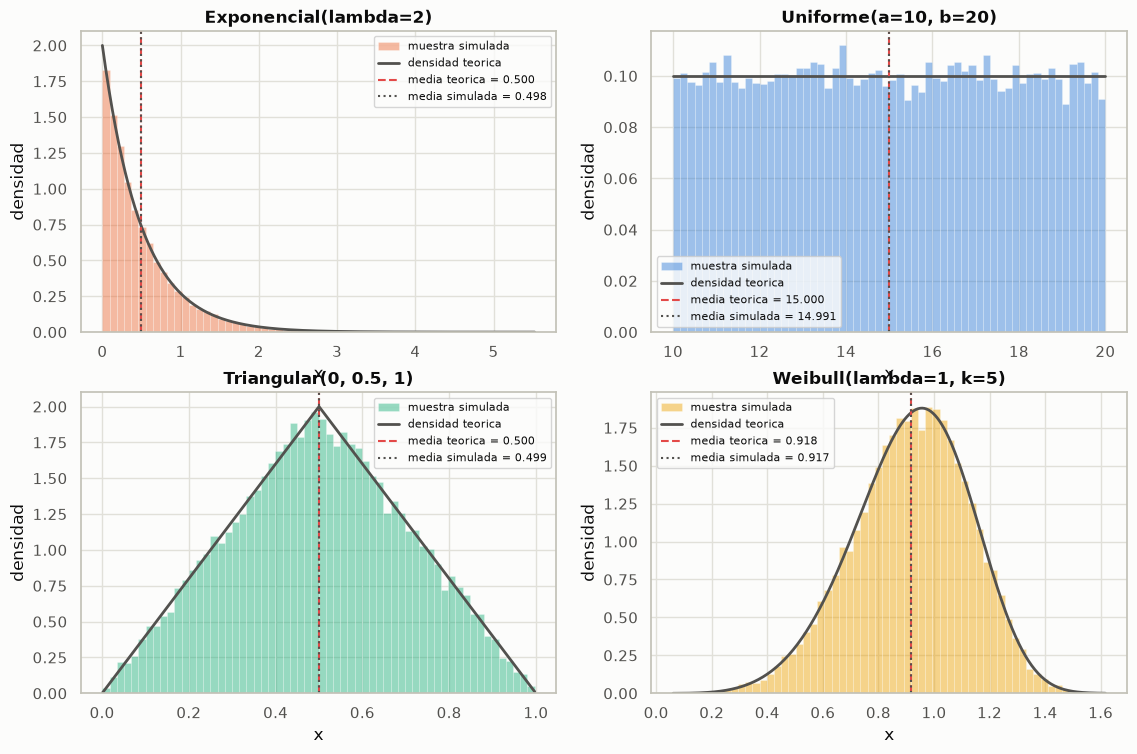

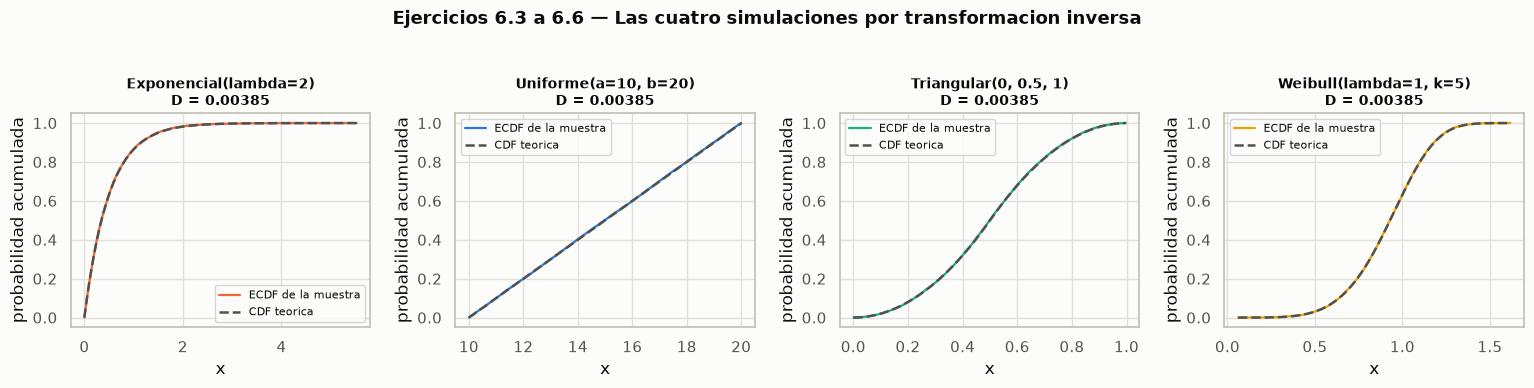

In [27]:
# Figura comparativa: las cuatro simulaciones en una rejilla
fig, ejes = plt.subplots(2, 2, figsize=(13.5, 8.6))
ejes = ejes.ravel()

for ax, (nombre, dist, muestra, color) in zip(ejes, distribuciones):
    minimo, maximo = muestra.min(), muestra.max()
    rejilla = np.linspace(minimo, maximo, 400)

    # Panel izquierdo: histograma empirico frente a la densidad teorica
    ax.hist(muestra, bins=60, density=True, color=color, alpha=0.45,
            edgecolor="white", linewidth=0.4, label="muestra simulada")
    ax.plot(rejilla, dist.pdf(rejilla), color=COLOR_NULO, linewidth=2.0,
            label="densidad teorica")
    media_teor = float(dist.mean())
    ax.axvline(media_teor, color=COLOR_CRITICAL, linestyle="--", linewidth=1.5,
               label=f"media teorica = {media_teor:.3f}")
    ax.axvline(muestra.mean(), color=COLOR_NULO, linestyle=":", linewidth=1.5,
               label=f"media simulada = {muestra.mean():.3f}")
    ax.set_title(nombre, fontweight="bold")
    ax.set_ylabel("densidad")
    ax.set_xlabel("x")
    ax.legend(frameon=True, fontsize=7.6)

# Fila inferior: ECDF empirica frente a la teorica
fig, ejes2 = plt.subplots(1, 4, figsize=(15.5, 3.9))
for ax, (nombre, dist, muestra, color) in zip(ejes2, distribuciones):
    ordenados = np.sort(muestra)
    paso_y = np.arange(1, ordenados.size + 1) / ordenados.size
    ax.plot(ordenados, paso_y, color=color, linewidth=1.6, label="ECDF de la muestra")
    ax.plot(rejilla if False else ordenados, dist.cdf(ordenados), color=COLOR_NULO,
            linestyle="--", linewidth=1.8, label="CDF teorica")
    ax.set_title(f"{nombre}\nD = {st.kstest(muestra, dist.cdf).statistic:.5f}", fontsize=10,
                 fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("probabilidad acumulada")
    ax.legend(frameon=True, fontsize=7.6)

fig.suptitle("Ejercicios 6.3 a 6.6 — Las cuatro simulaciones por transformacion inversa",
             fontsize=13, fontweight="bold", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

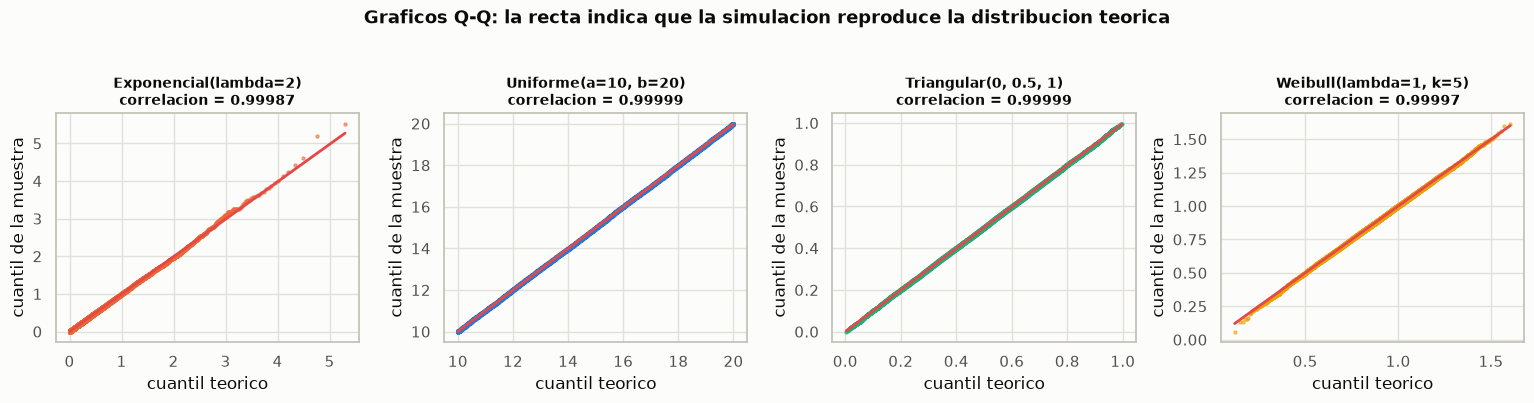

In [28]:
# Figura: graficos Q-Q de las cuatro simulaciones
fig, ejes = plt.subplots(1, 4, figsize=(15.5, 3.9))
for ax, (nombre, dist, muestra, color) in zip(ejes, distribuciones):
    ordenados = np.sort(muestra)
    p_orden = (np.arange(1, ordenados.size + 1) - 0.5) / ordenados.size
    teoricos = dist.ppf(p_orden)
    ax.plot(teoricos, ordenados, "o", color=color, markersize=2.2, alpha=0.55)
    pendiente, intercepto = np.polyfit(teoricos, ordenados, 1)
    min_teor, max_teor = teoricos.min(), teoricos.max()
    ax.plot([min_teor, max_teor], [pendiente * min_teor + intercepto,
                                   pendiente * max_teor + intercepto],
            color=COLOR_CRITICAL, linewidth=2.0)
    correlacion = float(np.corrcoef(teoricos, ordenados)[0, 1])
    ax.set_title(f"{nombre}\ncorrelacion = {correlacion:.5f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("cuantil teorico")
    ax.set_ylabel("cuantil de la muestra")

fig.suptitle("Graficos Q-Q: la recta indica que la simulacion reproduce la distribucion teorica",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

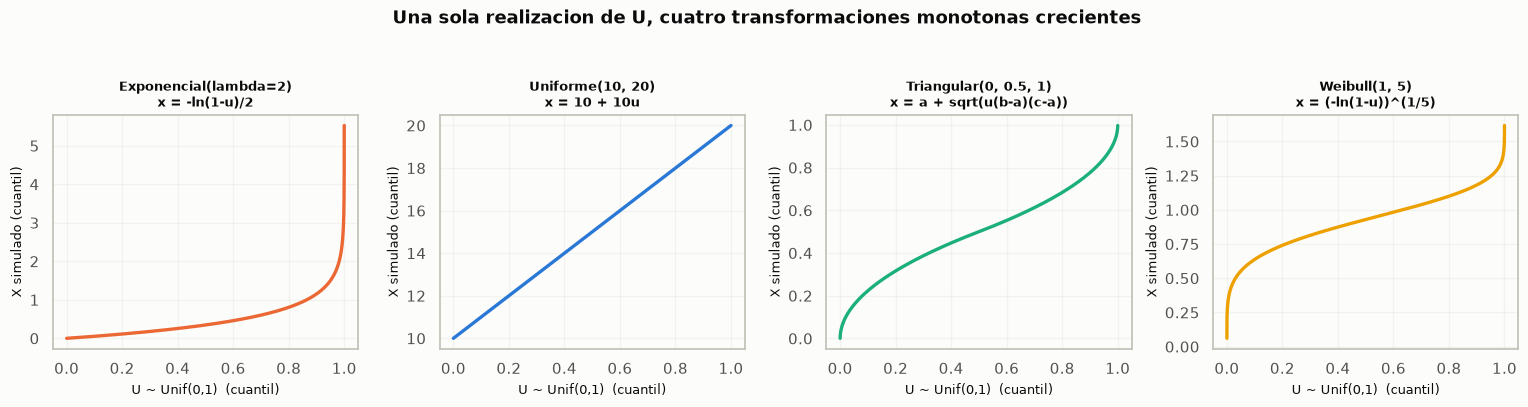

Las cuatro curvas son crecientes: el orden de los valores simulados coincide con el
orden de U. Esa monotonicidad es la razon por la que el estadistico D de Kolmogorov-
Smirnov resulta identico en las cuatro simulaciones.


In [29]:
# Figura: el mismo U, cuatro transformaciones (un panel por escala, para que
# la uniforme en [10, 20] no aplaste visualmente a las otras tres)
fig, ejes = plt.subplots(1, 4, figsize=(15.5, 3.9))
u_ordenado = np.sort(u_compartido)
curvas = [
    ("Exponencial(lambda=2)\nx = -ln(1-u)/2", np.sort(x_exp), COLOR_EXP),
    ("Uniforme(10, 20)\nx = 10 + 10u", np.sort(x_unif), COLOR_UNIF),
    ("Triangular(0, 0.5, 1)\nx = a + sqrt(u(b-a)(c-a))", np.sort(x_tri), COLOR_TRI),
    ("Weibull(1, 5)\nx = (-ln(1-u))^(1/5)", np.sort(x_wei), COLOR_WEI),
]
for ax, (titulo, valores, color) in zip(ejes, curvas):
    ax.plot(u_ordenado, valores, color=color, linewidth=2.4)
    ax.set_title(titulo, fontsize=9.5, fontweight="bold")
    ax.set_xlabel("U ~ Unif(0,1)  (cuantil)", fontsize=9)
    ax.set_ylabel("X simulado (cuantil)", fontsize=9)
    ax.grid(alpha=0.35)

fig.suptitle("Una sola realizacion de U, cuatro transformaciones monotonas crecientes",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()

print("Las cuatro curvas son crecientes: el orden de los valores simulados coincide con el")
print("orden de U. Esa monotonicidad es la razon por la que el estadistico D de Kolmogorov-")
print("Smirnov resulta identico en las cuatro simulaciones.")

<a id="resumen"></a>
## 12. Resumen comparativo

### 12.1 Pruebas sobre la muestra de 30 datos

| Ejercicio | Hipótesis $H_0$ | Estadístico | Valor | Valor $-p$ | $\alpha$ | Decisión |
|-----------|------------------|-------------|-------|-----------|-----------|----------|
| 6.1 rachas (umbral media) | la secuencia es aleatoria | $R = 19$ | $E[R] = 15.4$ | $0.1804$ (exacta) | $0.05$ | No se rechaza |
| 6.1 rachas (umbral mediana) | la secuencia es aleatoria | $R = 19$ | $E[R] = 16.0$ | $0.3498$ (exacta) | $0.05$ | No se rechaza |
| 6.2 KS | la muestra es Unif(0,1) | $D = 0.1855$ | $D_{crit} = 0.2417$ | $0.2239$ | $0.05$ | No se rechaza |
| 6.2 chi-cuadrado (4 clases) | la muestra es Unif(0,1) | $\chi^2 = 3.867$ | $\chi^2_{crit} = 7.815$ | $0.2762$ | $0.05$ | No se rechaza |
| 6.2 Kendall $\tau$ | no hay asociación orden-valor | $\tau = -0.0023$ | — | — | $0.05$ | No se rechaza |

### 12.2 Simulaciones por inversión

| Ejercicio | Distribución | Parámetros | $F^{-1}(u)$ | Media simulada | Media teórica | $D$ (KS) | Valor $-p$ |
|-----------|--------------|------------|-------------|----------------|---------------|----------|-----------|
| 6.3 | Exponencial | $\lambda = 2$ | $-\frac{1}{\lambda}\ln(1-u)$ | 0.497568 | 0.500000 | 0.003853 | 0.9268 |
| 6.4 | Uniforme | $a=10,\ b=20$ | $a + (b-a)u$ | 14.991454 | 15.000000 | 0.003853 | 0.9268 |
| 6.5 | Triangular | $a=0,\ c=0.5,\ b=1$ | dos ramas | 0.499332 | 0.500000 | 0.003853 | 0.9268 |
| 6.6 | Weibull | $\lambda=1,\ k=5$ | $\lambda[-\ln(1-u)]^{1/k}$ | 0.917472 | 0.918169 | 0.003853 | 0.9268 |

### 12.3 Verificación symbolic de las inversas

| Distribución | $F(F^{-1}(u))$ | ¿Se reduce a $u$? |
|--------------|------------------|---------------------|
| Exponencial | $u$ | Sí |
| Uniforme | $u$ | Sí |
| Triangular (rama izquierda) | $u$ | Sí |
| Triangular (rama derecha) | $u$ | Sí |
| Weibull | $u$ | Sí |


<a id="conclusiones"></a>
## 13. Conclusiones

### 13.1 Ejercicio 6.1 — La muestra es aleatoria

La muestra **sí es aleatoria** al nivel del 5 %. Con umbral en la media se observan
$R = 19$ rachas frente a las $E[R] = 15.4$ esperadas, con $z = 1.396$ y un valor $-p$ exacto de
$0.1804$; con umbral en la mediana se obtiene $R = 19$ frente a $E[R] = 16.0$, con
$-p = 0.3498$. Ambos resultados superan con holgura el umbral de $0.05$, y el barrido de umbrales
entre los cuantiles 20 % y 90 % no rechaza en ningún punto.

Hay un matiz que conviene no pasar por alto: el valor $-p$ exacto con umbral en la media
($0.1804$) es sensiblemente mayor que el de la mediana, y la aproximación normal sin corrección
por continuidad da $0.1628$ frente a $0.2294$ con corrección. Con $n = 30$ y $n_1 = 12$, la
aproximación normal es razonablemente buena pero no exacta, y por eso conviene reportar ambas.
Aun así, la distancia al umbral es amplia y la conclusión no queda en duda. El contraste con
Kendall, que no requiere umbral alguno, cierra el diagnóstico: con 218 pares discordantes de
435 (proporción $0.501$) se obtiene $\tau = -0.0023$, es decir, **el valor no guarda relación
con su posición**, que es exactamente lo que se espera de una muestra aleatoria.

Obsérvese que la desviación observada es hacia **más** rachas de las esperadas, no hacia menos:
la muestra alterna algo más que el azar puro, lo cual es compatible con $H_0$. Una muestra
claramente no aleatoria habría producido $R$ en los extremos, muy por debajo o muy por encima
de $E[R]$.

### 13.2 Ejercicio 6.2 — Los datos son compatibles con una Unif(0,1)

**Los datos se distribuyen como una $\mathrm{Unif}(0,1)$** en el sentido de que no se detectan
desviaciones al 5 %. El estadístico KS es $D = 0.1855$ frente a un valor crítico exacto de
$0.2417$ (y asintótico de $0.2480$), con valor $-p = 0.2239$. El chi-cuadrado con
cuatro clases equiprobables coincide ($p = 0.2762$).

La desviación más clara es el déficit de observaciones en $[0.50, 0.75)$ —4 frente a 7.5
esperadas—, responsable de que $D^+ = 0.1855$ supere a $D^- = 0.0534$. Se refleja en el Q–Q,
donde la pendiente ajustada es $0.91 < 1$. Con 30 observaciones esta magnitud es compatible con
la fluctuación ordinaria del muestreo, y por eso ninguna de las dos pruebas la convierte en
evidencia.

Conviene ser preciso con el alcance lógico del resultado: **no rechazar $H_0$ no es demostrar
$H_0$**. La prueba KS tiene potencia baja frente a desviaciones sutiles, de modo que la
conclusión correcta es «los datos son compatibles con una uniforme», no «los datos son
uniformes». Una forma de expresarlo sin ambigüedad es la que da el enunciado: se adopta la
primera proposición.

### 13.3 Ejercicios 6.3 a 6.6 — Las cuatro simulaciones son correctas

Las cuatro distribuciones se simularon correctamente por el método de inversión. En todos los
casos la comprobación simbólica $F(F^{-1}(u)) = u$ se reduce a $u$ de forma exacta, lo que
descarta errores de álgebra en las inversas, y todas las muestras pasan la prueba de
Kolmogorov–Smirnov con $D = 0.0039$ y valor $-p = 0.927$ muy por encima del $0.05$. Los momentos
empíricos reproducen los teóricos con errores relativos por debajo del $0.6 \%$ y los gráficos
Q–Q son rectas con correlación superior a $0.9999$.

Tres observaciones del contenido merece la pena destacar:

1. **La triangular exige un caso especial.** Su CDF no es invertible globalmente, sino que tiene
   dos ramas que se eligen según $u \leq u_0 = (c-a)/(b-a) = 0.5$. Es el único caso del
   ejercicio donde el método de inversión necesita una decisión explícita, y por eso su
   simulación no puede escribirse como una única expresión.
2. **El parámetro $\lambda$ de la Weibull del enunciado es la escala, no la media.** Como
   $F(\lambda) = 1 - e^{-1}$, $\lambda = 1$ corresponde al percentil 63.2 y la media real es
   $\Gamma(1.2) = 0.918$. Confundir ambos parámetros habría producido una simulación
   «centrada en 1» que en realidad no es Weibull con escala 1.
3. **La simulación no crea azar, lo transforma.** Las cuatro muestras se generaron de la misma
   realization de $U$, y por eso su estadístico KS es idéntico. Esta coincidencia es la
   manifestación más directa de que el método de inversión es una simple aplicación de una
   función monótona creciente a los cuantiles de una uniforme.

### 13.4 Conclusión general

Los seis ejercicios se resuelven con dos herramientas complementarias. Del lado de los datos,
las pruebas no paramétricas de rachas y de Kolmogorov–Smirnov confirman que la muestra de 30
valores se comporte como material aleatorio y compatible con una $\mathrm{Unif}(0,1)$, resultados
robustos a la elección del umbral y a la prueba utilizada. Del lado de la simulación, el método
de inversión se revela como un procedimiento general y verificable: basta con invertir la CDF,
y la identidad $F(F^{-1}(u)) = u$ más una prueba de bondad de ajuste confirman el resultado.

La lección común es que **la verificación es parte del resultado**. En la simulación, comprobar
simbólicamente la inversa y contrastar la muestra contra la distribución teórica evita
aceptar una fórmula plausible pero equivocada; en las pruebas, notar que no rechazar $H_0$ no
es demostrar $H_0$ evita una conclusión más fuerte que la que los datos sostienen. En ambos
casos el trabajo no termina al obtener un número: termina cuando ese número resiste una
comprobación independiente.
